# 09 — Tables de données : membres, tickers, panel annuel

**Objet.** Construire progressivement 4 fichiers CSV dans `tables/` :

| fichier | grain | lignes | contenu |
|---|---|---|---|
| `membres.csv` | 1 ligne = 1 membre | 372 | identité, activité, portefeuille, risque/perf, track record, comportement |
| `tickers.csv` | 1 ligne = 1 ticker | 4 618 | identité, flux Congrès, marché, croisement |
| `membres_annees.csv` | 1 ligne = (membre, année) | ~1 800 | activité et performance par année |
| `dictionnaire_colonnes.csv` | 1 ligne = 1 colonne | — | définition, source, type de chaque colonne |

**Principe.** Aucune stratégie ici : uniquement de la *donnée propre et comprise*. Chaque famille de
colonnes = une section : définitions mathématiques d'abord, calcul ensuite, validation à la fin.
Les CSV ne sont écrits qu'après la cellule de contrôles croisés (§12) : aucun fichier incohérent ne peut sortir.

**Comment lire ce document.** Chaque section suit le même schéma :
*définitions mathématiques → calcul → contrôles (`assert` sur des valeurs de référence recalculées
indépendamment) → aperçu du tableau → démonstration visuelle sur un membre*. Le membre et le ticker
de démonstration se choisissent au §1.2.

## §0.1 Notations (utilisées dans tout le notebook)

**Ensembles et indices**

$$m \in \mathcal{M} \;(\text{membres, clé } \texttt{bioguide\_id}), \qquad
k \in \mathcal{K} \;(\text{tickers, clé } \texttt{ticker\_yahoo}), \qquad
j \;(\text{trade}), \qquad t \in \mathrm{cal}$$

- $\mathrm{cal}$ = calendrier de bourse maître (index des prix SPY, 2012-2026).
- Trade $j$ : $\big(m_j,\; k_j,\; d_j,\; \tau_j,\; A_j\big)$ avec $d_j \in \{\text{buy}, \text{sell}\}$,
  $\tau_j$ = date de **transaction** (`traded`), $A_j$ = montant midpoint (`size_usd`).
- Deux périmètres : $\mathcal{T}^{brut}$ = table canonique filtrée aux années 2013-2026 (**134 429** trades,
  372 membres, 4 618 tickers) ; $\mathcal{T} \subset \mathcal{T}^{brut}$ = trades dont le ticker a un prix
  exploitable (**118 029** trades, 3 289 tickers) — tout ce qui touche aux prix ou au portefeuille est calculé sur $\mathcal{T}$.

**Prix et portefeuille reconstruit (entrée à la date de transaction $\tau_j$)**

$$P_k(t) = \text{prix ajusté, forward-fill sur } \mathrm{cal} \qquad\quad
n_k^m(t) = \text{parts FIFO détenues par } m \text{ (pas de short)}$$

$$V_m(t) = \sum_k n_k^m(t)\,P_k(t), \qquad
w_k^m(t) = \frac{n_k^m(t)\,P_k(t)}{V_m(t)}, \qquad
r_m(t) = \frac{\sum_k n_k^m(t{-}1)\,P_k(t)}{\sum_k n_k^m(t{-}1)\,P_k(t{-}1)} - 1$$

- $r_m$ est *time-weighted* (insensible aux apports), winsorisé à $\pm 50\,\%$/jour,
  restreint aux jours actifs ($V_m > 0$) ; $T_m$ = nombre de jours actifs ; $r_{SPY}(t)$ = rendement du SPY.
- $x_j$ = excès de rendement du trade $j$ (défini au §5bis).

**Exclusions assumées** : options/produits dérivés (absents des PTR collectés), montants exacts
(brackets STOCK Act $\Rightarrow$ midpoint = mesure censurée par intervalle), saisonnalité par membre.

## §1 Le moteur

Quatre briques, utilisées par toutes les sections :

1. la table des trades déclarés, réduite à (membre, ticker, sens, date de transaction, montant) ;
2. les prix ajustés de chaque titre et le calendrier de bourse (l'index du SPY) ;
3. la reconstruction du portefeuille de chaque membre : parts détenues $n_k^m(t)$ (FIFO, pas de
   short), valeur $V_m(t)$, rendement quotidien time-weighted $r_m(t)$ ;
4. les fonctions de mesure : Sharpe, information ratio, $\alpha/\beta$, durées de détention,
   matrice comité $\to$ secteurs.

Le §1.1 vérifie le périmètre et des valeurs de référence recalculées indépendamment.

In [1]:
# — imports et chemins —
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices_v2")

In [2]:
# — la table des trades déclarés : (membre, ticker, sens, date, montant) —
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df = (df.drop(columns=["ticker"])
        .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                         "direction": "op", "transaction_date": "traded",
                         "amount_midpoint": "size_usd"}))
n0 = len(df)
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]]
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")

134464 -> 134429 trades  |  372 membres  |  4618 tickers


In [3]:
# — le SPY : benchmark et calendrier de bourse maître —
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché

In [4]:
# — les prix ajustés, alignés sur le calendrier ; garde-fou anti-corruption —
# (cache local complet : exécution 100 % hors-ligne)
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))} - {"failed_v2"}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)
prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()
corrompus = [tk for tk in need if (len(prices[tk].dropna()) < 2
             or prices[tk].dropna().min() < 0.10
             or prices[tk].dropna().pct_change().abs().max() > 3.0)]   # <0,10$ ou saut >300%/j
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]
n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)} | sans prix : {len(missing)} | corrompus exclus : {len(corrompus)} | trades jetés : {n_drop}  => {len(df)} exploitables")

tickers avec prix : 3289 | sans prix : 1268 | corrompus exclus : 61 | trades jetés : 16400  => 118029 exploitables


In [5]:
# — la reconstruction FIFO : du flux de trades aux parts détenues n_k^m(t) —
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marché)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

def member_shares(g):
    # g = trades d'un membre  ->  N (parts détenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

In [6]:
# — le rendement quotidien time-weighted r_m(t) et les statistiques de base —
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Σ n_i(t-1) P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Σ n_i(t-1) P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # winsorisation ±50 %/jour
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr, vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

In [7]:
# — une série de rendement par membre —
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


In [8]:
# — dfx : la table complète (owner, secteurs, dates de déclaration…), même périmètre que df —
_raw = pd.read_csv(CLEAN, low_memory=False)
dfx = (_raw.drop(columns=["ticker"])
           .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                            "direction": "op", "transaction_date": "traded",
                            "amount_midpoint": "size_usd"}))
dfx["traded"] = pd.to_datetime(dfx["traded"], errors="coerce")
dfx["disclosure_date"] = pd.to_datetime(dfx["disclosure_date"], errors="coerce")
dfx = dfx[dfx["traded"].dt.year.between(2013, 2026)]
dfx = dfx[dfx["ticker"].isin(set(need))].reset_index(drop=True)
assert len(dfx) == len(df), (len(dfx), len(df))

# owner normalisé + nom canonique par bioguide
OWNER = {"Spouse":"conjoint","SP":"conjoint","SELF":"élu","Self":"élu",
         "JT":"joint","Joint Tenancy":"joint","Joint":"joint",
         "Dependent Child":"enfant","DC":"enfant","Child":"enfant"}
dfx["owner_n"] = dfx["owner"].map(OWNER)
_name_canon = dfx.groupby("bioguide_id")["name"].agg(lambda s: s.mode().iloc[0])
dfx["name_canon"] = dfx["bioguide_id"].map(_name_canon)
print(f"dfx : {len(dfx)} trades × {dfx.shape[1]} colonnes | owner_n couvert : {dfx.owner_n.notna().mean():.0%} | "
      f"{dfx.bioguide_id.nunique()} membres")

dfx : 118029 trades × 37 colonnes | owner_n couvert : 100% | 359 membres


In [9]:
# dfb = version 𝒯^brut de dfx (AVANT le filtre ticker-avec-prix) — mêmes renommages, mêmes années
dfb = (_raw.drop(columns=["ticker"])
           .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                            "direction": "op", "transaction_date": "traded",
                            "amount_midpoint": "size_usd"}))
dfb["traded"] = pd.to_datetime(dfb["traded"], errors="coerce")
_hors_annees = int((~dfb["traded"].dt.year.between(2013, 2026)).sum())
dfb = dfb[dfb["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
dfb["owner_n"] = dfb["owner"].map(OWNER)
print(f"𝒯^brut : {len(dfb)} trades ({_hors_annees} hors 2013-2026 écartés de la table canonique {len(_raw)}) | "
      f"{dfb.bioguide_id.nunique()} membres | {dfb.ticker.nunique()} tickers")

𝒯^brut : 134429 trades (35 hors 2013-2026 écartés de la table canonique 134464) | 372 membres | 4618 tickers


In [10]:
# — mesures relatives au marché : information ratio, alpha, beta —
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

def alpha_beta(r):
    # Régression r = alpha + beta*r_spy + eps -> beta, alpha annualisé, appraisal, t_appr
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, appraisal=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)      # pente, ordonnée
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = (alpha / se * np.sqrt(252)) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, appraisal=appr,
                t_appr=appr * np.sqrt(len(d) / 252))

In [11]:
# — durées de détention (FIFO), survie de Kaplan-Meier, excès de CAGR, Sortino —
from collections import deque
LAST_DAY = cal.max()

def fifo_holding(g):
    closed, opened = [], []          # (durée_j, parts) fermés ; (durée_censurée_j, parts) ouverts
    for tk, gt in g.groupby("ticker"):
        lots = deque()
        for _, row in gt.sort_values("traded").iterrows():        # MÊME tri que member_shares
            dd, p = eff_price(tk, row["traded"])
            if dd is None: continue
            q = row["size_usd"] / p
            if row["op"] == "buy":
                lots.append([dd, q])
            else:
                held = sum(l[1] for l in lots); qv = min(q, held); take_tot = qv
                while take_tot > 1e-12 and lots:
                    tau_b, parts = lots[0]; take = min(parts, take_tot)
                    closed.append(((dd - tau_b).days, take)); take_tot -= take
                    if parts - take <= 1e-12: lots.popleft()
                    else: lots[0][1] = parts - take
        for tau_b, parts in lots:
            if parts > 1e-9:
                opened.append(((LAST_DAY - tau_b).days, parts))
    return closed, opened

def km_weighted(closed, opened):                       # Kaplan-Meier pondéré par les parts
    ev = pd.DataFrame({"t": closed.duree, "w": closed.parts, "event": 1})
    ce = pd.DataFrame({"t": opened.duree, "w": opened.parts, "event": 0})
    alld = pd.concat([ev, ce]).sort_values("t")
    times = np.sort(ev["t"].unique())
    S = 1.0
    xs, ys = [0], [1.0]
    for t in times:
        at_risk = alld.loc[alld.t >= t, "w"].sum()
        d = ev.loc[ev.t == t, "w"].sum()
        if at_risk > 0:
            S *= (1 - d / at_risk)
        xs.append(t); ys.append(S)
    return np.array(xs), np.array(ys)

def exces_spy(bid):
    r = wf_ret[bid]; nav = (1+r).cumprod(); cagr = nav.iloc[-1]**(252/len(r))-1
    rs = r_spy.reindex(r.index).fillna(0.0); navs = (1+rs).cumprod(); cagrs = navs.iloc[-1]**(252/len(rs))-1
    return cagr - cagrs

def sortino(r):
    d = r.dropna(); dn = d[d < 0].std()
    return d.mean() / dn * np.sqrt(252) if dn > 0 else np.nan

In [12]:
# — matrice comité → secteurs GICS (jurisdictions officielles) + parsing des codes THOMAS —
SECTEURS = ["Information Technology", "Financials", "Health Care", "Industrials",
            "Consumer Discretionary", "Communication Services", "Consumer Staples",
            "Energy", "Materials", "Real Estate", "Utilities"]

COMITE_GICS = {   # chaque ligne justifiée par le champ jurisdiction officiel du comité
    "HSAG": {"Consumer Staples", "Materials"},          "SSAF": {"Consumer Staples", "Materials"},
    "HSAS": {"Industrials"},  "SSAS": {"Industrials"},  "HLIG": {"Industrials"},
    "HSHM": {"Industrials", "Information Technology"},
    "HSBA": {"Financials", "Real Estate"},              "SSBK": {"Financials", "Real Estate"},
    "HSIF": {"Energy", "Utilities", "Health Care", "Communication Services"},
    "HSII": {"Energy", "Materials", "Utilities"},       "SSEG": {"Energy", "Utilities", "Materials"},
    "SSEV": {"Utilities", "Materials", "Industrials"},  "HSPW": {"Industrials", "Utilities"},
    "SSCM": {"Industrials", "Communication Services", "Information Technology"},
    "HSWM": {"Health Care", "Financials"},              "SSFI": {"Health Care", "Financials"},
    "HSSY": {"Information Technology"},                 "SSHR": {"Health Care"},
    "HSVR": {"Health Care"},
    # transverses → ∅ (les inclure viderait « aligné » de son sens)
    "HSAP": set(), "SSAP": set(), "HSGO": set(), "SSGA": set(), "HSRU": set(), "HSHA": set(),
    "HSJU": set(), "SSJU": set(), "HSFA": set(), "SSFR": set(), "HSSM": set(), "HSED": set(),
}

import re
def codes_racine(s):
    if not isinstance(s, str):
        return frozenset()
    return frozenset(t.strip()[:4] for t in s.split(";") if re.fullmatch(r"[A-Z]{4}\d*", t.strip()))

### §1.1 Contrôles du moteur

Le périmètre exact ($|\mathcal{T}| = 118\,029$ trades, $3\,289$ tickers avec prix, $266$ membres
reconstruits, $223$ éligibles) et des valeurs de référence recalculées indépendamment sur les 2 plus
gros traders (Khanna, McCaul) sont vérifiés par `assert` : si un seul chiffre bouge, tout s'arrête ici.

In [13]:
# (i) le périmètre attendu
assert len(df) == 118029 and len(dfx) == 118029, len(df)
assert len(need) == 3289, len(need)
assert len(wf_ret) == 266, len(wf_ret)
assert len(dfb) == 134429 and dfb.bioguide_id.nunique() == 372, (len(dfb), dfb.bioguide_id.nunique())

# (ii) éligibilité : n_trades ≥ 10 et T_m ≥ 126 jours actifs
_nt = df.groupby("bioguide_id").size()
_nd = pd.Series({b: len(r) for b, r in wf_ret.items()})
_eligible = ((_nt.reindex(_nd.index) >= 10) & (_nd >= 126))
assert int(_eligible.sum()) == 223, int(_eligible.sum())

# (iii) valeurs de référence sur les 2 plus gros traders (Khanna puis McCaul)
for _bid, _n, _ntk, _sh in [("K000389", 32684, 975, 0.87), ("M001157", 16028, 582, 0.61)]:
    assert int(_nt[_bid]) == _n, (_bid, int(_nt[_bid]))
    assert dfx.loc[dfx.bioguide_id == _bid, "ticker"].nunique() == _ntk
    assert round(stats(wf_ret[_bid])["sharpe"], 2) == _sh, (_bid, stats(wf_ret[_bid])["sharpe"])
print("§1.1 OK — périmètre 118 029 / 3 289 / 266 / 223 ; contrôles Khanna et McCaul exacts")

§1.1 OK — périmètre 118 029 / 3 289 / 266 / 223 ; contrôles Khanna et McCaul exacts


## §1.2 La personne (et le ticker) de démonstration

Chaque famille de colonnes est illustrée **sur un membre** avant d'être calculée pour tous.
Changer le nom (ou le ticker) ci-dessous puis *Run All* : toutes les démos suivent.

In [14]:
DEMO = "Nancy Pelosi"        # ← change le nom ici (sous-chaîne, insensible à la casse)
TICKER_DEMO = "NVDA"         # ← change le ticker de démo ici (doit avoir un prix)

_hits = dfx.loc[dfx["name_canon"].str.contains(DEMO, case=False, na=False), ["bioguide_id", "name_canon"]].drop_duplicates()
if len(_hits) == 0:
    import difflib
    _prches = difflib.get_close_matches(DEMO, dfx["name_canon"].unique().tolist(), n=5, cutoff=0.3)
    raise ValueError(f"aucun membre ne contient « {DEMO} » — noms proches : {_prches}")
if len(_hits) > 1:
    print("plusieurs membres correspondent, on prend le 1er :", _hits["name_canon"].tolist())
DEMO_BID = _hits["bioguide_id"].iloc[0]
DEMO_NOM = _hits["name_canon"].iloc[0]
assert TICKER_DEMO in need, f"{TICKER_DEMO} n'a pas de prix exploitable"
if DEMO_BID not in wf_ret:
    print(f"⚠ {DEMO_NOM} n'a pas de portefeuille reconstruit — les démos §4.2/§5.2/§6.2 demanderont un autre membre")
# couleurs cohérentes de toutes les démos
C_BUY, C_SELL, C_M, C_SPY = "tab:green", "tab:red", "tab:blue", "0.45"
print(f"démos sur : {DEMO_NOM} ({DEMO_BID}) | ticker : {TICKER_DEMO}")

démos sur : Nancy Pelosi (P000197) | ticker : NVDA


## §2 `membres` — famille A : identité et mandat

**But** : qui est chaque membre — parti, chambre, État, mandat, postes de direction, comités, et les
secteurs économiques que ces comités supervisent.

Squelette : $\mathcal{M}$ = les 372 `bioguide_id` de $\mathcal{T}^{brut}$. Définitions
(les agrégats sont pris sur $\mathcal{T}^{brut}$, l'identité ne dépend pas de la couverture prix) :

$$\texttt{name} = \operatorname{mode}(\text{variantes du nom}), \qquad
\texttt{party},\ \texttt{chamber} = \operatorname{mode}, \qquad
\texttt{state} = \texttt{state\_district}[{:}2]$$

$$\texttt{comites}(m) = \bigcup_j \operatorname{codes}(\texttt{committee\_membership}_j), \qquad
\texttt{secteurs\_juridiction}(m) = \bigcup_{c \in \texttt{comites}(m)} \mathrm{COMITE\_GICS}[c]$$

`leader` et `leader_postes` viennent du fichier vérifié `leadership_2014_2026.csv` (12 postes de parti) ;
`years_in_office` de `table_congres_2014_2026.csv`.

In [15]:
def _mode(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

_ab = dfb.groupby("bioguide_id")
M = pd.DataFrame(index=pd.Index(sorted(dfb.bioguide_id.unique()), name="bioguide_id"))
M["name"] = _ab["name"].agg(_mode)
M.loc[M.index.isin(_name_canon.index), "name"] = _name_canon        # nom canonique 𝒯 prioritaire
M["party"] = _ab["party"].agg(_mode)
M["chamber"] = _ab["chamber"].agg(_mode)
M["state"] = _ab["state_district"].agg(_mode).astype(str).str[:2]
M["congress_first"] = _ab["congress"].min()
M["congress_last"] = _ab["congress"].max()

_tc = pd.read_csv(os.path.join(BASE, "table_congres_2014_2026.csv"), low_memory=False)
M["years_in_office"] = _tc.dropna(subset=["bioguide_id"]).groupby("bioguide_id")["years_in_office"].max()

_lead = pd.read_csv(os.path.join(BASE, "leadership_2014_2026.csv"))
M["leader"] = M.index.isin(set(_lead["bioguide_id"]))
_postes = _lead.groupby("bioguide_id")["poste"].agg(lambda s: "|".join(sorted(set(s))))
M["leader_postes"] = M.index.map(_postes)

_codes_m = _ab["committee_membership"].agg(lambda s: frozenset().union(*s.map(codes_racine)))
M["comites"] = _codes_m.map(lambda cs: "|".join(sorted(cs)))
M["comite_cle"] = _ab["committees_key_flag"].agg(lambda s: bool(pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any()))
_juri = _codes_m.map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs]) if cs else frozenset())
M["secteurs_juridiction"] = _juri.map(lambda ss: "|".join(sorted(ss)))
M["n_secteurs_juridiction"] = _juri.map(len)
print(f"M : {len(M)} membres × {M.shape[1]} colonnes")
M.head(3)

M : 372 membres × 13 colonnes


,name,party,chamber,state,congress_first,congress_last,years_in_office,leader,leader_postes,comites,comite_cle,secteurs_juridiction,n_secteurs_juridiction
bioguide_id,,,,,,,,,,,,,
A000055,Robert B. Aderholt,Republican,house,AL,117,119,28.0,False,NaN,HSAP,False,,0
A000148,Jake Auchincloss,Democrat,house,MA,118,119,5.0,False,NaN,HSIF|HSPW,False,Communication Services|Energy|Health Care|Indu...,5
A000210,Robert E. Andrews,Democrat,house,NJ,113,113,23.0,False,NaN,,False,,0


### §2.1 Validation

In [16]:
assert len(M) == 372 and M.index.is_unique
assert M["name"].notna().all() and (M["state"].str.len() == 2).all()
assert M["leader"].sum() == _lead["bioguide_id"].nunique() - len(set(_lead["bioguide_id"]) - set(M.index)), "leaders hors périmètre ?"
_n_lead_dans_T = len(set(_lead["bioguide_id"]) & set(wf_ret))
assert _n_lead_dans_T == 8, _n_lead_dans_T          # valeur de référence : 8 leaders reconstruits
assert (M["n_secteurs_juridiction"] <= 11).all()
print(f"§2.1 OK — 372 lignes, clé unique | {int(M.leader.sum())} leaders au total, {_n_lead_dans_T} parmi les reconstruits")

§2.1 OK — 372 lignes, clé unique | 10 leaders au total, 8 parmi les reconstruits


**Aperçu (tableau)** — famille A, 8 premières lignes :

In [17]:
M[["name", "party", "chamber", "state", "congress_first", "congress_last", "years_in_office",
   "leader", "comites", "secteurs_juridiction"]].head(8)

,name,party,chamber,state,congress_first,congress_last,years_in_office,leader,comites,secteurs_juridiction
bioguide_id,,,,,,,,,,
A000055,Robert B. Aderholt,Republican,house,AL,117,119,28.0,False,HSAP,
A000148,Jake Auchincloss,Democrat,house,MA,118,119,5.0,False,HSIF|HSPW,Communication Services|Energy|Health Care|Indu...
A000210,Robert E. Andrews,Democrat,house,NJ,113,113,23.0,False,,
A000367,Justin Amash,Republican,house,MI,114,116,9.0,False,HSGO,
A000372,Richard W. Allen,Republican,house,GA,115,119,11.0,False,HSAG|HSED|HSIF,Communication Services|Consumer Staples|Energy...
A000373,Brad Ashford,Democrat,house,NE,114,114,1.0,False,HSAG|HSAS,Consumer Staples|Industrials|Materials
A000378,Cindy Axne,Democrat,house,IA,116,117,3.0,False,HSAG|HSBA,Consumer Staples|Financials|Materials|Real Estate
A000379,Mark Alford,Republican,house,MO,119,119,3.0,False,HSAP|HSSM,


### §2.2 Démo — la carte d'identité (famille A) du membre choisi

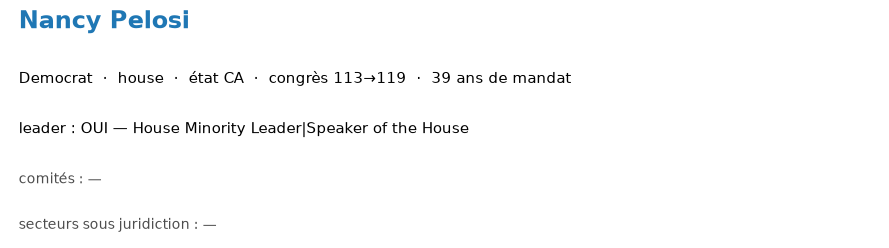

In [18]:
_r = M.loc[DEMO_BID]
fig, ax = plt.subplots(figsize=(9, 2.6)); ax.axis("off")
ax.text(0.01, 0.92, DEMO_NOM, size=17, weight="bold", color=C_M, transform=ax.transAxes)
ax.text(0.01, 0.68, f"{_r['party']}  ·  {_r['chamber']}  ·  état {_r['state']}  ·  "
                    f"congrès {int(_r['congress_first'])}→{int(_r['congress_last'])}  ·  "
                    f"{'' if _r['years_in_office'] != _r['years_in_office'] else str(int(_r['years_in_office'])) + ' ans de mandat'}",
        size=11, transform=ax.transAxes)
ax.text(0.01, 0.46, f"leader : {'OUI — ' + str(_r['leader_postes']) if _r['leader'] else 'non'}",
        size=11, transform=ax.transAxes)
ax.text(0.01, 0.24, f"comités : {_r['comites'] or '—'}", size=10, color="0.3", transform=ax.transAxes)
ax.text(0.01, 0.04, f"secteurs sous juridiction : {_r['secteurs_juridiction'] or '—'}",
        size=10, color="0.3", transform=ax.transAxes)
plt.tight_layout(); plt.show()

## §3 `membres` — famille B : activité de déclaration, temps de présence

**But** : comment le membre déclare — volumes, montants, délais de déclaration, qui trade dans le
foyer, et depuis/jusqu'à quand il est « dans le jeu ».

Sur $\mathcal{T}$, sauf $\texttt{n\_trades\_brut}$ compté sur $\mathcal{T}^{brut}$ :

$$\texttt{buy\_share} = \frac{\#\{j : d_j = \text{buy}\}}{\#\{j\}}, \qquad
\texttt{notional\_x} = \sum_{j \,:\, d_j = x} A_j, \qquad
\texttt{pct\_1re\_fourchette} = \mathbb{P}\big(A_j \le 8\,000{,}5\big)$$

$$\texttt{lag\_med} = \operatorname{med}_j(\texttt{lag\_days}_j), \qquad
\texttt{part\_late} = \mathbb{P}(\texttt{lag} > 45\,\text{j}), \qquad
\texttt{part\_very\_late} = \mathbb{P}(\texttt{lag} > 365\,\text{j})$$

$$\texttt{duree\_activite\_j} = \max_j \tau_j - \min_j \tau_j, \qquad
\texttt{actif\_12m} = \mathbb{1}\big\{\max_j \tau_j \ge \max(\mathrm{cal}) - 365\,\text{j}\big\}$$

In [19]:
_ax = dfx.groupby("bioguide_id")
M["n_trades_brut"] = _ab.size()
M["n_trades"] = _ax.size()
M["n_buy"] = _ax["op"].agg(lambda s: int((s == "buy").sum()))
M["n_sell"] = _ax["op"].agg(lambda s: int((s == "sell").sum()))
M["buy_share"] = _ax["op"].agg(lambda s: (s == "buy").mean())
M["notional_total"] = _ax["size_usd"].sum()
M["notional_buy"] = dfx[dfx.op == "buy"].groupby("bioguide_id")["size_usd"].sum()
M["notional_sell"] = dfx[dfx.op == "sell"].groupby("bioguide_id")["size_usd"].sum()
M["taille_med"] = _ax["size_usd"].median()
M["pct_1re_fourchette"] = _ax["size_usd"].agg(lambda s: (s <= 8000.5).mean())
M["lag_med"] = _ax["lag_days"].median()
M["part_late"] = _ax["flag_late_filing"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).mean())
M["part_very_late"] = _ax["flag_very_late_filing"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).mean())
M["owner_dom"] = _ax["owner_n"].agg(_mode)
M["part_conjoint"] = _ax["owner_n"].agg(lambda s: (s == "conjoint").mean())
M["part_self"] = _ax["owner_n"].agg(lambda s: (s == "élu").mean())
M["first_trade"] = _ax["traded"].min().dt.date
M["last_trade"] = _ax["traded"].max().dt.date
M["duree_activite_j"] = (_ax["traded"].max() - _ax["traded"].min()).dt.days
M["n_annees_actives"] = _ax["traded"].agg(lambda s: s.dt.year.nunique())
M["actif_12m"] = _ax["traded"].max() >= (cal.max() - pd.Timedelta(days=365))
print(f"M : {M.shape[1]} colonnes après famille B")

M : 34 colonnes après famille B


### §3.1 Validation

In [20]:
assert int(M["n_trades_brut"].sum()) == 134429
assert int(M["n_trades"].fillna(0).sum()) == 118029
assert int((M["n_buy"].fillna(0) + M["n_sell"].fillna(0)).sum()) == 118029
# valeurs de référence (Khanna)
assert round(float(M.loc["K000389", "buy_share"]), 2) == 0.57
assert round(float(M.loc["K000389", "part_conjoint"]), 2) == 0.65
assert pd.Timestamp(M["first_trade"].dropna().min()) == df["traded"].min()
assert M.loc[M["n_trades"].notna(), "lag_med"].notna().all()
print(f"§3.1 OK — Σ brut 134 429, Σ 𝒯 118 029 | Khanna buy_share 0,57 / conjoint 0,65 | "
      f"membres actifs sur 12 derniers mois : {int(M.actif_12m.sum())}")

§3.1 OK — Σ brut 134 429, Σ 𝒯 118 029 | Khanna buy_share 0,57 / conjoint 0,65 | membres actifs sur 12 derniers mois : 103


**Aperçu (tableau)** — famille B, les 8 membres les plus actifs :

In [21]:
(M.sort_values("n_trades", ascending=False)
  [["name", "n_trades", "n_buy", "n_sell", "buy_share", "notional_total", "taille_med",
    "lag_med", "first_trade", "last_trade", "duree_activite_j", "actif_12m"]]
  .head(8).round(3))

,name,n_trades,n_buy,n_sell,buy_share,notional_total,taille_med,lag_med,first_trade,last_trade,duree_activite_j,actif_12m
bioguide_id,,,,,,,,,,,,
K000389,Rohit Khanna,32684.0,18469.0,14215.0,0.565,520291341.5,8000.5,25.0,2017-01-05,2026-05-28,3430.0,True
M001157,Michael T. McCaul,16028.0,7304.0,8724.0,0.456,784625529.0,8000.5,35.0,2013-12-03,2026-05-29,4560.0,True
R000586,James B. Renacci,3978.0,2148.0,1830.0,0.540,76941989.0,8000.5,14.0,2013-12-30,2018-12-12,1808.0,False
G000583,Josh Gottheimer,3054.0,1257.0,1797.0,0.412,33514027.0,8000.5,28.0,2017-01-03,2026-05-27,3431.0,True
R000582,David P. Roe,3003.0,1275.0,1728.0,0.425,42514001.5,8000.5,29.0,2013-12-09,2020-11-30,2548.0,False
M001193,Thomas MacArthur,2617.0,1388.0,1229.0,0.530,89603308.5,8000.5,26.0,2015-01-06,2018-12-31,1455.0,False
H001086,Diana Harshbarger,2519.0,972.0,1547.0,0.386,369774434.5,8000.5,36.0,2021-01-04,2023-02-16,773.0,False
C001123,Gilbert Cisneros,2283.0,1332.0,951.0,0.583,24753641.5,8000.5,27.0,2019-01-18,2026-06-30,2720.0,True


### §3.2 Démo — l'activité (famille B) : chaque point est un trade $j$ ($\tau_j$, $A_j$)

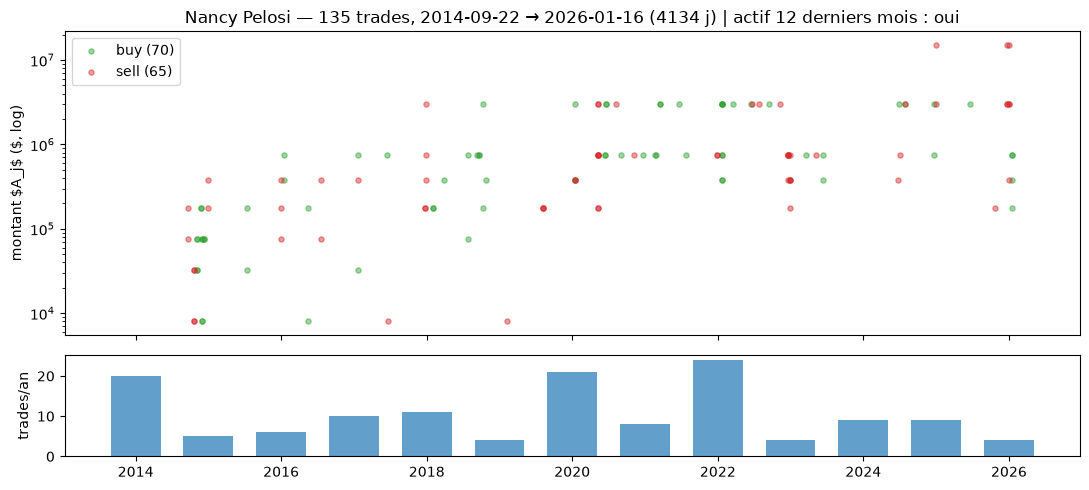

buy_share 52% | taille médiane 750,000 $ | lag médian de déclaration 26 j | owner dominant : conjoint


In [22]:
_g = dfx[dfx.bioguide_id == DEMO_BID]
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
for _dop, _dc in [("buy", C_BUY), ("sell", C_SELL)]:
    _ds = _g[_g.op == _dop]
    ax[0].scatter(_ds["traded"], _ds["size_usd"], s=14, alpha=.45, color=_dc,
                  label=f"{_dop} ({len(_ds):,})")
ax[0].set_yscale("log"); ax[0].set_ylabel("montant $A_j$ ($, log)"); ax[0].legend(loc="upper left")
_r = M.loc[DEMO_BID]
ax[0].set_title(f"{DEMO_NOM} — {int(_r['n_trades'])} trades, {str(_r['first_trade'])} → {str(_r['last_trade'])} "
                f"({int(_r['duree_activite_j'])} j) | actif 12 derniers mois : {'oui' if _r['actif_12m'] else 'non'}")
_par_an = _g.groupby(_g["traded"].dt.year).size()
ax[1].bar(pd.to_datetime(_par_an.index, format="%Y"), _par_an.values, width=250, color=C_M, alpha=.7)
ax[1].set_ylabel("trades/an")
plt.tight_layout(); plt.show()
print(f"buy_share {_r['buy_share']:.0%} | taille médiane {_r['taille_med']:,.0f} $ | "
      f"lag médian de déclaration {_r['lag_med']:.0f} j | owner dominant : {_r['owner_dom']}")

## §4 `membres` — famille C (1/3) : la passe portefeuille unique

**But** : à quoi ressemble le portefeuille reconstruit de chaque membre — sa taille, sa
concentration, sa rotation.

Une **seule** boucle sur les 266 membres reconstruits : $N = n^m$ (matrice parts) est calculée
une fois, on en tire toutes les statistiques, puis $N$ est jetée (mémoire) :

$$\mathrm{HHI}_m = \overline{\Big(\sum_k w_k^m(t)^2\Big)}_{t\,:\,V_m>0}, \qquad
N^{e\!f\!f}_m = \frac{1}{\mathrm{HHI}_m}, \qquad
\texttt{top1}_m = \overline{\max_k w_k^m(t)}$$

$$\texttt{turnover}_m = \frac{\sum_j A_j}{2\,\bar V_m} \cdot \frac{252}{T_m}, \qquad
\bar V_m = \overline{V_m(t)}_{V_m > 0}$$

Les épisodes FIFO (achat $\to$ vente appariée) sont stockés **par membre** pour le §6.

In [23]:
PORT, EPIS = {}, {}
for b in wf_ret:
    g = df[df.bioguide_id == b]
    N = member_shares(g)
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    NP = N * P
    V = NP.sum(axis=1); act = V > 0
    W = NP.div(V, axis=0)[act]
    hhi = float((W ** 2).sum(axis=1).mean())
    vbar = float(V[act].mean())
    PORT[b] = dict(
        hhi=hhi, n_eff=1 / hhi if hhi > 0 else np.nan,
        top1=float(W.max(axis=1).mean()),
        n_pos_moy=float((N[act] > 0).sum(axis=1).mean()),
        valeur_moy=vbar, valeur_fin=float(V.iloc[-1]),
        turnover=(g["size_usd"].sum() / (2 * vbar) * 252 / int(act.sum()))
                 if (vbar > 0 and act.sum() >= 2) else np.nan)
    EPIS[b] = fifo_holding(g)
    del N, P, NP, V, W
_port = pd.DataFrame(PORT).T
for c in _port.columns:
    M[c] = _port[c]
M["reconstruit"] = M.index.isin(wf_ret)
M["n_days"] = pd.Series({b: len(r) for b, r in wf_ret.items()})
M["n_tickers"] = dfx.groupby("bioguide_id")["ticker"].nunique()
M["n_episodes_fermes"] = pd.Series({b: len(c) for b, (c, o) in EPIS.items()})
print(f"passe unique : {len(PORT)} membres | colonnes portefeuille jointes")

passe unique : 266 membres | colonnes portefeuille jointes


### §4.1 Validation — contre-calcul indépendant, mêmes totaux

In [24]:
# (i) contre-calcul : la concentration recalculée par une fonction écrite séparément, sur 3 membres
def concentration(bid):                                 # version de contrôle indépendante
    g = df[df.bioguide_id == bid]; N = member_shares(g)
    if N is None: return None
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    V = (N*P).sum(axis=1); act = V > 0
    if act.sum() == 0: return None
    W = (N*P).div(V, axis=0)[act]
    hhi = (W**2).sum(axis=1).mean()
    return dict(hhi=hhi, n_eff=1/hhi if hhi>0 else np.nan, top1=W.max(axis=1).mean(),
                n_pos_moy=(N[act]>0).sum(axis=1).mean())
for _b in ["K000389", "M001157", "P000197"]:
    _ref = concentration(_b)
    for _k in ("hhi", "n_eff", "top1", "n_pos_moy"):
        assert abs(_ref[_k] - M.loc[_b, _k]) < 1e-9, (_b, _k)

# (ii) totaux des épisodes de détention : 61 963 fermés / 28 944 encore ouverts
_cl = pd.DataFrame([e for c, o in EPIS.values() for e in c], columns=["duree", "parts"])
_op = pd.DataFrame([e for c, o in EPIS.values() for e in o], columns=["duree", "parts"])
assert (len(_cl), len(_op)) == (61963, 28944), (len(_cl), len(_op))
_pct_open = _op.parts.sum() / (_cl.parts.sum() + _op.parts.sum())
assert round(_pct_open, 2) == 0.44, _pct_open
# (iii) médiane de survie tous membres confondus ≈ 910 jours
_kx, _ky = km_weighted(_cl, _op)
_med_km_pool = _kx[np.searchsorted(-_ky, -0.5)]
assert abs(_med_km_pool - 910) <= 5, _med_km_pool
print(f"§4.1 OK — concentration/turnover identiques | épisodes 61 963/28 944, encore détenu 44 % | KM pooled {_med_km_pool:.0f} j")

§4.1 OK — concentration/turnover identiques | épisodes 61 963/28 944, encore détenu 44 % | KM pooled 910 j


**Aperçu (tableau)** — portefeuille reconstruit, les 8 plus gros portefeuilles moyens :

In [25]:
(M[M.reconstruit].sort_values("valeur_moy", ascending=False)
  [["name", "n_days", "n_tickers", "valeur_moy", "hhi", "n_eff", "top1", "n_pos_moy",
    "turnover", "n_episodes_fermes"]]
  .head(8).round(3))

,name,n_days,n_tickers,valeur_moy,hhi,n_eff,top1,n_pos_moy,turnover,n_episodes_fermes
bioguide_id,,,,,,,,,,
M001157,Michael T. McCaul,3163.0,582.0,1.423252e+08,0.081,12.315,0.175,185.009,0.220,9828.0
H001086,Diana Harshbarger,1380.0,173.0,1.377267e+08,0.043,23.028,0.094,96.297,0.245,928.0
K000389,Rohit Khanna,2373.0,975.0,9.364756e+07,0.007,142.239,0.033,582.011,0.295,22532.0
A000373,Brad Ashford,2853.0,15.0,7.029621e+07,0.991,1.010,0.995,6.549,0.024,6.0
C001035,Susan M Collins,3146.0,179.0,4.234744e+07,0.828,1.207,0.890,57.556,0.039,69.0
F000062,DIANNE FEINSTEIN,2152.0,52.0,4.063682e+07,0.056,17.819,0.112,29.637,0.163,241.0
R000586,James B. Renacci,3145.0,557.0,2.919568e+07,0.011,93.245,0.035,298.770,0.106,1998.0
P000197,Nancy Pelosi,2914.0,33.0,2.884926e+07,0.335,2.985,0.430,9.638,0.266,54.0


### §4.2 Démo — le portefeuille reconstruit : $V_m(t)$ et les poids $w_k^m(t)$ des 8 plus grosses positions

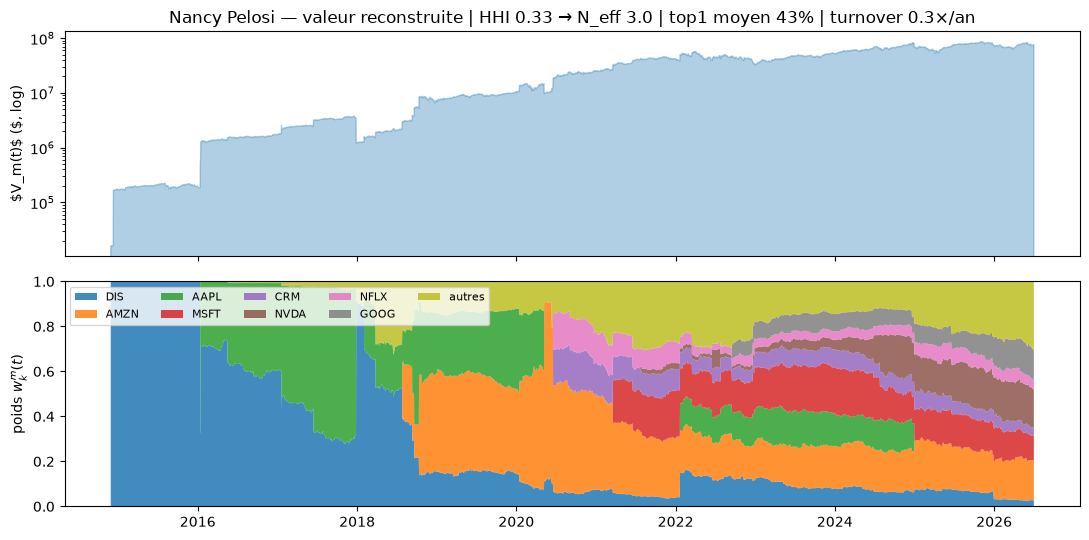

In [26]:
assert DEMO_BID in wf_ret, "membre non reconstruit : choisis-en un autre au §1.2"
_N = member_shares(df[df.bioguide_id == DEMO_BID])
_P = pd.DataFrame({tk: prices[tk] for tk in _N.columns})
_V = (_N * _P).sum(axis=1); _act = _V > 0
_W = (_N * _P).div(_V, axis=0)[_act]
_top8 = _W.mean().sort_values(ascending=False).head(8).index
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax[0].fill_between(_V[_act].index, _V[_act].values, color=C_M, alpha=.35)
ax[0].set_yscale("log"); ax[0].set_ylabel("$V_m(t)$ ($, log)")
_r = M.loc[DEMO_BID]
ax[0].set_title(f"{DEMO_NOM} — valeur reconstruite | HHI {_r['hhi']:.2f} → N_eff {_r['n_eff']:.1f} | "
                f"top1 moyen {_r['top1']:.0%} | turnover {_r['turnover']:.1f}×/an")
_Wp = _W[_top8].clip(lower=0)
_Wp["autres"] = (1 - _Wp.sum(axis=1)).clip(lower=0)
ax[1].stackplot(_Wp.index, [_Wp[c].values for c in _Wp.columns], labels=list(_Wp.columns), alpha=.85)
ax[1].set_ylim(0, 1); ax[1].set_ylabel("poids $w_k^m(t)$"); ax[1].legend(ncol=5, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()
del _N, _P, _V, _W, _Wp

## §5 `membres` — famille D : risque et performance

**But** : le risque et la performance du portefeuille de chaque membre — volatilité, Sharpe,
alpha/bêta contre le marché — mesurés sur sa série de rendement quotidienne $r_m$.

$$\texttt{cagr}_m = NAV_m(T_m)^{252/T_m} - 1, \qquad
\texttt{vol}_m = \sigma(r_m)\sqrt{252}, \qquad
\texttt{sharpe}_m = \frac{\bar r_m}{\sigma(r_m)}\sqrt{252}, \qquad
\texttt{sortino}_m = \frac{\bar r_m}{\sigma(r_m^-)}\sqrt{252}$$

$$\texttt{ir}_m = \frac{\overline{r_m - r_{SPY}}}{\sigma(r_m - r_{SPY})}\sqrt{252}, \qquad
t_{IR} = \mathrm{IR}\sqrt{T_m/252}, \qquad
r_m = \alpha + \beta\, r_{SPY} + \varepsilon
\;\Rightarrow\; \texttt{appraisal}_m = \frac{\alpha}{\sigma_\varepsilon}\sqrt{252}$$

La `vol` d'un portefeuille à 1 titre est la vol du titre : c'est une valeur **vraie**, à lire avec
`n_eff` et `eligible` ($n \ge 10$ trades et $T_m \ge 126$ j).

In [27]:
_rows = {}
for b, r in wf_ret.items():
    st = stats(r); ab = alpha_beta(r)
    T = len(r)
    _rows[b] = dict(cagr=st["cagr"], vol=st["vol"], sharpe=st["sharpe"], maxdd=st["maxdd"],
                    sortino=sortino(r),
                    t_sharpe=st["sharpe"] * np.sqrt(T / 252) if np.isfinite(st["sharpe"]) else np.nan,
                    ir=info_ratio(r), beta=ab["beta"], alpha_ann=ab["alpha_ann"],
                    appraisal=ab["appraisal"], t_appr=ab["t_appr"],
                    exces_cagr_spy=exces_spy(b))
_perf = pd.DataFrame(_rows).T
_perf["t_ir"] = _perf["ir"] * np.sqrt(M["n_days"].reindex(_perf.index) / 252)
for c in _perf.columns:
    M[c] = _perf[c]
M["eligible"] = (M["n_trades"].fillna(0) >= 10) & (M["n_days"].fillna(0) >= 126)
print(f"famille D : {len(_perf)} membres | éligibles : {int(M.eligible.sum())}")

famille D : 266 membres | éligibles : 223


### §5.1 Validation

In [28]:
assert int(M["eligible"].sum()) == 223
assert round(float(M.loc["K000389", "sharpe"]), 2) == 0.87            # valeur de référence (Khanna)
assert round(float(M.loc["M001157", "sharpe"]), 2) == 0.61
# cohérence interne : sharpe = cagr-like sign, |beta| raisonnable pour les éligibles
_e = M[M.eligible]
assert _e["vol"].between(0, 3).all() and _e["beta"].dropna().between(-2, 5).all()
print(f"§5.1 OK — 223 éligibles | Khanna 0,87 / McCaul 0,61 | vol médiane éligibles {_e.vol.median():.1%}")

§5.1 OK — 223 éligibles | Khanna 0,87 / McCaul 0,61 | vol médiane éligibles 20.4%


**Aperçu (tableau)** — risque/performance, les 8 éligibles les plus actifs :

In [29]:
(M[M.eligible].sort_values("n_trades", ascending=False)
  [["name", "cagr", "vol", "sharpe", "sortino", "maxdd", "beta", "alpha_ann", "ir", "exces_cagr_spy"]]
  .head(8).round(3))

,name,cagr,vol,sharpe,sortino,maxdd,beta,alpha_ann,ir,exces_cagr_spy
bioguide_id,,,,,,,,,,
K000389,Rohit Khanna,0.155,0.186,0.870,1.048,-0.376,0.978,0.006,0.044,0.002
M001157,Michael T. McCaul,0.104,0.191,0.614,0.769,-0.391,1.020,-0.030,-0.372,-0.035
R000586,James B. Renacci,0.108,0.164,0.708,0.872,-0.343,0.928,-0.017,-0.671,-0.029
G000583,Josh Gottheimer,0.145,0.198,0.783,0.996,-0.319,1.044,-0.012,-0.085,-0.009
R000582,David P. Roe,0.141,0.175,0.843,1.052,-0.348,0.987,0.004,0.058,0.002
M001193,Thomas MacArthur,0.105,0.163,0.696,0.844,-0.349,0.887,-0.016,-0.638,-0.034
H001086,Diana Harshbarger,0.152,0.175,0.898,1.269,-0.165,0.903,0.018,0.039,0.003
C001123,Gilbert Cisneros,0.179,0.220,0.857,1.074,-0.370,1.087,-0.000,0.230,0.011


### §5.2 Démo — risque/performance : la NAV de $r_m$ contre le SPY sur la même fenêtre

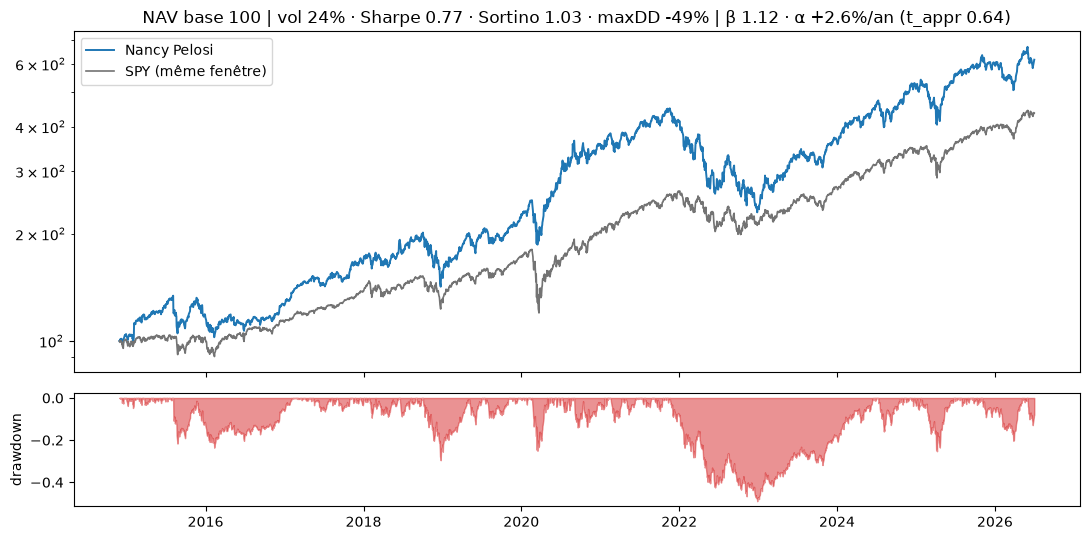

excès de CAGR vs SPY : +3.4%/an | IR 0.31 (t 1.06) | T = 2914 jours actifs | éligible : oui


In [30]:
assert DEMO_BID in wf_ret, "membre non reconstruit : choisis-en un autre au §1.2"
_rm = wf_ret[DEMO_BID]
_nav = (1 + _rm).cumprod() * 100
_rs = r_spy.reindex(_rm.index).fillna(0.0); _navs = (1 + _rs).cumprod() * 100
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(_nav, color=C_M, lw=1.4, label=DEMO_NOM)
ax[0].plot(_navs, color=C_SPY, lw=1.2, label="SPY (même fenêtre)")
ax[0].set_yscale("log"); ax[0].legend()
_r = M.loc[DEMO_BID]
ax[0].set_title(f"NAV base 100 | vol {_r['vol']:.0%} · Sharpe {_r['sharpe']:.2f} · Sortino {_r['sortino']:.2f} · "
                f"maxDD {_r['maxdd']:.0%} | β {_r['beta']:.2f} · α {_r['alpha_ann']:+.1%}/an (t_appr {_r['t_appr']:.2f})")
ax[1].fill_between(_nav.index, (_nav / _nav.cummax() - 1).values, color=C_SELL, alpha=.5)
ax[1].set_ylabel("drawdown")
plt.tight_layout(); plt.show()
print(f"excès de CAGR vs SPY : {_r['exces_cagr_spy']:+.1%}/an | IR {_r['ir']:.2f} (t {_r['t_ir']:.2f}) | "
      f"T = {int(_r['n_days'])} jours actifs | éligible : {'oui' if _r['eligible'] else 'non'}")

## §5bis `membres` — famille F : le track record par trade

**But** : le talent trade par trade — pour chaque achat, le titre a-t-il battu le marché entre
l'achat et la revente (plafonnée à un an) ?

Pour chaque **achat** $j$ : entrée au close de $J{+}1(\tau_j)$, sortie au close de
$t^s_j = \min\big(J{+}1(\text{première vente du même } (m, k) \text{ après } \tau_j),\; J{+}1(\tau_j) + 252\big)$,
**brut de coûts** (c'est le talent du membre, pas la stratégie d'un copieur) :

$$x_j = \frac{P_{k_j}(t^s_j)}{P_{k_j}(J{+}1(\tau_j))} - \frac{SPY(t^s_j)}{SPY(J{+}1(\tau_j))}
\qquad\quad
x^{raw}_j = \frac{P_{k_j}(t^s_j)}{P_{k_j}(J{+}1(\tau_j))} - 1$$

$$\texttt{hit\_rate} = \mathbb{P}(x_j > 0), \quad
\texttt{profit\_factor} = \min\Big(\frac{\sum x_j^+}{|\sum x_j^-|},\, 10\Big), \quad
t_x = \frac{\bar x}{\sigma_x / \sqrt{n}}$$

In [31]:
# appariement : chaque achat -> première vente ultérieure du même (membre, ticker)
_b = dfx[dfx.op == "buy"][["bioguide_id", "ticker", "traded"]].sort_values("traded").reset_index()
_s = (dfx[dfx.op == "sell"][["bioguide_id", "ticker", "traded"]].dropna()
      .sort_values("traded").rename(columns={"traded": "sortie_vente"}))
_paires = pd.merge_asof(_b, _s, left_on="traded", right_on="sortie_vente",
                        by=["bioguide_id", "ticker"], direction="forward", allow_exact_matches=False)
_b["sortie_vente"] = _paires["sortie_vente"].values

# excès vectorisé : entrée J+1 de la transaction, sortie min(vente, +252 j), brut de coûts
px = pd.DataFrame(prices)                       # prix déjà forward-fillés sur le calendrier
PXV = px.to_numpy(); SPYV = spy.to_numpy()
COL = {tk: i for i, tk in enumerate(px.columns)}
# garde anti-prix périmé : dernier jour de VRAIE cotation par ticker (fichier brut, pas le ffill)
_last_true = {}
for tk in need:
    _d = pd.read_csv(os.path.join(PRICES, tk + ".csv"), usecols=["Date"])["Date"]
    _last_true[tk] = cal.searchsorted(pd.Timestamp(_d.iloc[-1]), side="right") - 1
_LAST = np.array([_last_true[tk] for tk in px.columns])

HOLD_MAX = 252
i0 = cal.searchsorted(pd.DatetimeIndex(_b["traded"]), side="right")
i_v = cal.searchsorted(pd.DatetimeIndex(pd.Series(_b["sortie_vente"]).fillna(cal[-1])), side="right")
i1 = np.where(_b["sortie_vente"].isna(), i0 + HOLD_MAX, np.minimum(i_v, i0 + HOLD_MAX))
i1 = np.minimum(np.maximum(i1, i0 + 1), len(cal) - 1)
cols = np.array([COL.get(t, -1) for t in _b["ticker"]])
ok = (cols >= 0) & (i0 < len(cal) - 1) & (i0 <= _LAST[np.maximum(cols, 0)])   # entrée sur une vraie cote
x = np.full(len(_b), np.nan); xr = np.full(len(_b), np.nan)
r_, c0, c1 = cols[ok], i0[ok], np.asarray(i1)[ok]
p0, p1 = PXV[c0, r_], PXV[c1, r_]
b0, b1 = SPYV[c0], SPYV[c1]
valid = ~(np.isnan(p0) | np.isnan(p1)) & (p0 > 0) & (b0 > 0)
_res = np.full(int(ok.sum()), np.nan); _resr = np.full(int(ok.sum()), np.nan)
_res[valid] = (p1[valid] / p0[valid] - 1) - (b1[valid] / b0[valid] - 1)
_resr[valid] = p1[valid] / p0[valid] - 1
x[ok] = _res; xr[ok] = _resr
_b["x"], _b["x_raw"] = x, xr
_bt = _b.dropna(subset=["x"])
print(f"{len(_bt):,} achats évalués / {len(_b):,} | excès moyen brut {_bt.x.mean():+.2%} | médiane {_bt.x.median():+.2%}")

58,926 achats évalués / 59,984 | excès moyen brut -0.23% | médiane -1.62%


In [32]:
_g = _bt.groupby("bioguide_id")["x"]
M["n_trades_evalues"] = _g.size()
M["hit_rate"] = _g.agg(lambda a: (a > 0).mean())
M["exces_moyen_trade"] = _g.mean()
M["exces_med_trade"] = _g.median()
M["ret_brut_moyen_trade"] = _bt.groupby("bioguide_id")["x_raw"].mean()
M["profit_factor"] = _g.agg(lambda a: min(a[a > 0].sum() / abs(a[a <= 0].sum()), 10.0)
                            if (a <= 0).any() and a[a <= 0].sum() != 0 else 10.0)
M["t_exces_trade"] = _g.agg(lambda a: a.mean() / (a.std(ddof=1) / np.sqrt(len(a)) + 1e-12)
                            if len(a) > 1 else np.nan)
print(f"famille F : {int(M.n_trades_evalues.notna().sum())} membres avec track record")

famille F : 267 membres avec track record


### §5bis.1 Validation — un trade recalculé à la main + bornes

In [33]:
# (i) un achat NVDA de Pelosi, recalculé pas à pas
# (ancré sur Pelosi en dur : la validation ne dépend PAS du membre de démo choisi au §1.2)
PELOSI_BID = df.loc[df["name"] == "Nancy Pelosi", "bioguide_id"].iloc[0]
_ex = _bt[(_bt.bioguide_id == PELOSI_BID) & (_bt.ticker == "NVDA")].iloc[0]
_i0 = cal.searchsorted(_ex["traded"], side="right")
_iv = cal.searchsorted(_ex["sortie_vente"], side="right") if pd.notna(_ex["sortie_vente"]) else _i0 + HOLD_MAX
_i1 = min(max(min(_iv, _i0 + HOLD_MAX), _i0 + 1), len(cal) - 1)
_pn = prices["NVDA"]
_x_main = (_pn.iloc[_i1] / _pn.iloc[_i0] - 1) - (spy.iloc[_i1] / spy.iloc[_i0] - 1)
assert abs(_x_main - _ex["x"]) < 1e-12, (_x_main, _ex["x"])
# (ii) bornes et cohérences
assert (M["n_trades_evalues"].fillna(0) <= M["n_buy"].fillna(0)).all()
assert M["hit_rate"].dropna().between(0, 1).all()
assert M["profit_factor"].dropna().between(0, 10).all()
# (iii) ordre de grandeur : l'excès moyen par trade doit rester en dessous de 5 % en absolu
assert abs(_bt.x.mean()) < 0.05
print(f"§5bis.1 OK — le trade recalculé à la main est identique au vectorisé ({_x_main:+.2%}) | "
      f"excès moyen tous trades {_bt.x.mean():+.2%}")

§5bis.1 OK — le trade recalculé à la main est identique au vectorisé (-4.15%) | excès moyen tous trades -0.23%


**Aperçu (tableau)** — track record par trade, les 8 plus gros échantillons :

In [34]:
(M.sort_values("n_trades_evalues", ascending=False)
  [["name", "n_trades_evalues", "hit_rate", "exces_moyen_trade", "exces_med_trade",
    "ret_brut_moyen_trade", "profit_factor", "t_exces_trade"]]
  .head(8).round(3))

,name,n_trades_evalues,hit_rate,exces_moyen_trade,exces_med_trade,ret_brut_moyen_trade,profit_factor,t_exces_trade
bioguide_id,,,,,,,,
K000389,Rohit Khanna,18398.0,0.402,-0.007,-0.020,0.038,0.879,-4.764
M001157,Michael T. McCaul,6971.0,0.465,0.004,-0.007,0.090,1.056,1.424
R000586,James B. Renacci,2050.0,0.482,0.002,-0.007,0.071,1.029,0.446
M001193,Thomas MacArthur,1362.0,0.392,-0.018,-0.019,0.042,0.701,-3.819
C001123,Gilbert Cisneros,1323.0,0.428,0.030,-0.031,0.170,1.283,2.650
R000582,David P. Roe,1257.0,0.448,-0.006,-0.014,0.074,0.919,-0.893
G000583,Josh Gottheimer,1253.0,0.433,-0.000,-0.033,0.091,0.999,-0.007
H001086,Diana Harshbarger,972.0,0.509,-0.007,0.002,0.020,0.900,-1.085


### §5bis.2 Démo — le track record par trade : distribution des $x_j$ du membre

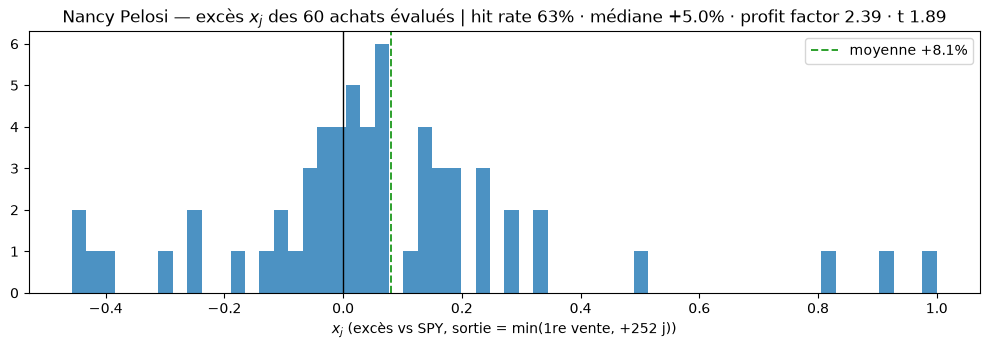

In [35]:
_x = _bt.loc[_bt.bioguide_id == DEMO_BID, "x"]
_r = M.loc[DEMO_BID]
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(_x.clip(-1, 1), bins=60, color=C_M, alpha=.8)
ax.axvline(0, color="k", lw=1)
ax.axvline(_x.mean(), color=C_BUY if _x.mean() > 0 else C_SELL, ls="--", lw=1.4,
           label=f"moyenne {_x.mean():+.1%}")
ax.set_title(f"{DEMO_NOM} — excès $x_j$ des {int(_r['n_trades_evalues'])} achats évalués | "
             f"hit rate {_r['hit_rate']:.0%} · médiane {_r['exces_med_trade']:+.1%} · "
             f"profit factor {_r['profit_factor']:.2f} · t {_r['t_exces_trade']:.2f}")
ax.set_xlabel("$x_j$ (excès vs SPY, sortie = min(1re vente, +252 j))"); ax.legend()
plt.tight_layout(); plt.show()

## §6 `membres` — famille C (2/3) : durées de détention par membre

**But** : combien de temps chaque membre garde ses positions.

Sur les épisodes FIFO du §4 (achat $\to$ vente appariée ; épisodes encore ouverts = **censurés**) :

$$\texttt{duree\_med\_fermee}_m = \operatorname{med}_w(\text{durées closes}), \qquad
\texttt{duree\_km\_med}_m = \inf\{t : \hat S_m(t) \le 0{,}5\}$$

$$\texttt{part\_ouverte}_m = \frac{\sum_{ouverts} q}{\sum_{clos} q + \sum_{ouverts} q}, \qquad
\texttt{n\_allers\_retours\_30j}_m = \#\{\text{épisodes clos} < 30 \text{ j}\}$$

$\hat S_m$ = estimateur de Kaplan-Meier pondéré par les parts.
`duree_km_med` = NaN quand $> 50\,\%$ des parts sont encore détenues (buy-and-holder) : c'est une
information, à lire avec `part_ouverte`.

In [36]:
def _med_ponderee(d, w):
    # médiane pondérée : premier d (trié) dont le cumul des poids atteint 50 %
    o = np.argsort(d); d, w = np.asarray(d)[o], np.asarray(w)[o]
    cw = np.cumsum(w)
    return float(d[np.searchsorted(cw, 0.5 * cw[-1])])

_rows = {}
for b, (c, o) in EPIS.items():
    cl = pd.DataFrame(c, columns=["duree", "parts"]); op = pd.DataFrame(o, columns=["duree", "parts"])
    row = dict(part_ouverte=op.parts.sum() / (cl.parts.sum() + op.parts.sum())
               if (cl.parts.sum() + op.parts.sum()) > 0 else np.nan,
               n_allers_retours_30j=int((cl.duree < 30).sum()))
    row["duree_med_fermee"] = _med_ponderee(cl.duree.values, cl.parts.values) if len(cl) else np.nan
    if len(cl):
        kx, ky = km_weighted(cl, op)
        row["duree_km_med"] = float(kx[np.searchsorted(-ky, -0.5)]) if ky.min() <= 0.5 else np.nan
    else:
        row["duree_km_med"] = np.nan
    _rows[b] = row
_dur = pd.DataFrame(_rows).T
for c in _dur.columns:
    M[c] = _dur[c]
print(f"durées : {len(_dur)} membres | KM médiane atteinte pour {int(M.duree_km_med.notna().sum())} membres")

durées : 266 membres | KM médiane atteinte pour 125 membres


### §6.1 Validation — mini-exemple synthétique + cohérence pooled

In [37]:
# (i) exemple synthétique : 2 épisodes clos (10 j, poids 1) et (100 j, poids 1), 0 ouvert
#     -> med pondérée = 10 (cumul 50 % atteint au 1er) ; KM : S(10)=0,5 -> médiane = 10
_clt = pd.DataFrame({"duree": [10, 100], "parts": [1.0, 1.0]})
_opt = pd.DataFrame({"duree": [], "parts": []})
assert _med_ponderee(_clt.duree.values, _clt.parts.values) == 10
_kxt, _kyt = km_weighted(_clt, _opt)
assert float(_kxt[np.searchsorted(-_kyt, -0.5)]) == 10.0
# (ii) part encore détenue agrégée (pondérée parts) = 44 %
_tot_cl = sum(pd.DataFrame(c, columns=["duree", "parts"]).parts.sum() for c, o in EPIS.values())
_tot_op = sum(pd.DataFrame(o, columns=["duree", "parts"]).parts.sum() for c, o in EPIS.values())
assert round(_tot_op / (_tot_cl + _tot_op), 2) == 0.44
print("§6.1 OK — synthétique exact | part encore détenue pooled 44 %")

§6.1 OK — synthétique exact | part encore détenue pooled 44 %


**Aperçu (tableau)** — durées de détention, les 8 membres aux plus nombreux épisodes :

In [38]:
(M.sort_values("n_episodes_fermes", ascending=False)
  [["name", "n_episodes_fermes", "duree_med_fermee", "duree_km_med", "part_ouverte",
    "n_allers_retours_30j"]]
  .head(8).round(3))

,name,n_episodes_fermes,duree_med_fermee,duree_km_med,part_ouverte,n_allers_retours_30j
bioguide_id,,,,,,
K000389,Rohit Khanna,22532.0,435.0,1021.0,0.434,575.0
M001157,Michael T. McCaul,9828.0,499.0,1124.0,0.415,530.0
R000586,James B. Renacci,1998.0,286.0,618.0,0.404,93.0
G000583,Josh Gottheimer,1745.0,393.0,549.0,0.229,45.0
R000582,David P. Roe,1705.0,210.0,304.0,0.226,138.0
M001193,Thomas MacArthur,1296.0,161.0,309.0,0.323,167.0
P000612,"David A Perdue , Jr",1265.0,389.0,504.0,0.185,48.0
H001086,Diana Harshbarger,928.0,277.0,NaN,0.773,187.0


### §6.2 Démo — combien de temps garde-t-il ? Survie $\hat S_m(t)$ vs l'ensemble des membres

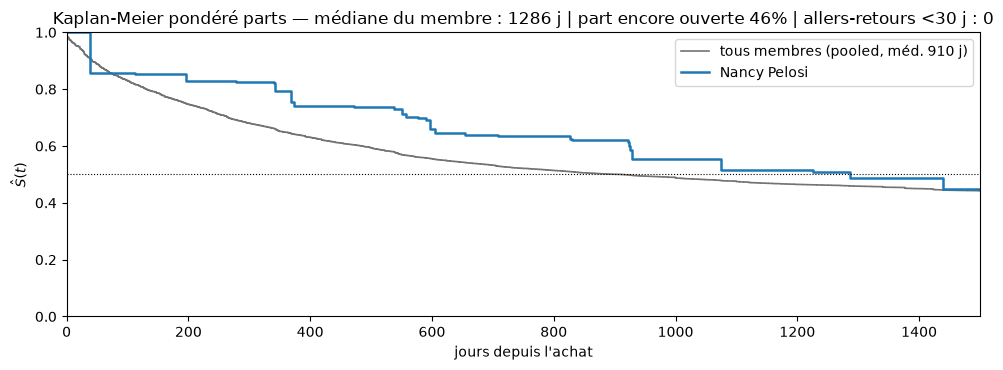

In [39]:
assert DEMO_BID in wf_ret, "membre non reconstruit : choisis-en un autre au §1.2"
_cE, _oE = EPIS[DEMO_BID]
_cld = pd.DataFrame(_cE, columns=["duree", "parts"]); _opd = pd.DataFrame(_oE, columns=["duree", "parts"])
_kxm, _kym = km_weighted(_cld, _opd)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.step(_kx, _ky, where="post", color=C_SPY, lw=1.2, label="tous membres (pooled, méd. 910 j)")
ax.step(_kxm, _kym, where="post", color=C_M, lw=1.8, label=DEMO_NOM)
ax.axhline(0.5, color="k", ls=":", lw=0.8)
_r = M.loc[DEMO_BID]
_med_txt = f"{_r['duree_km_med']:.0f} j" if _r['duree_km_med'] == _r['duree_km_med'] else "non atteinte (>50 % encore détenu)"
ax.set_title(f"Kaplan-Meier pondéré parts — médiane du membre : {_med_txt} | "
             f"part encore ouverte {_r['part_ouverte']:.0%} | allers-retours <30 j : {int(_r['n_allers_retours_30j'])}")
ax.set_xlabel("jours depuis l'achat"); ax.set_ylabel("$\\hat S(t)$"); ax.set_ylim(0, 1); ax.set_xlim(0, 1500); ax.legend()
plt.tight_layout(); plt.show()

## §7 `membres` — famille C (3/3) : actions principales et secteurs

**But** : quelles actions et quels secteurs dominent les achats de chaque membre.

Par **notional d'achat** (auditables sans reconstruction ; la mesure « poids quotidien » reste `top1`) :

$$\texttt{topK\_part}_m = \frac{\sum_{j\,:\,k_j = \text{topK},\, d_j = \text{buy}} A_j}{\texttt{notional\_buy}_m},
\qquad
\texttt{sect\_s}_m = \frac{\sum_{j\,:\,\mathrm{GICS}(k_j) = s,\, d_j = \text{buy}} A_j}{\texttt{notional\_buy}_m},
\qquad \sum_s \texttt{sect\_s}_m = 1$$

In [40]:
_buys = dfx[dfx.op == "buy"]
_mk = _buys.groupby(["bioguide_id", "ticker"])["size_usd"].sum().sort_values(ascending=False)
_top = (_mk.groupby(level=0).head(10).reset_index()
        .sort_values(["bioguide_id", "size_usd"], ascending=[True, False]))
_tl = _top.groupby("bioguide_id").agg(tks=("ticker", list), usd=("size_usd", list))
for i in (1, 2, 3):
    M[f"top{i}_ticker"] = _tl["tks"].map(lambda l: l[i - 1] if len(l) >= i else np.nan)
    M[f"top{i}_part"] = _tl["usd"].map(lambda l: l[i - 1] if len(l) >= i else np.nan) / M["notional_buy"]
M["top10_tickers"] = _tl["tks"].map("|".join)

SECT_COLS = {"Information Technology": "sect_info_tech", "Financials": "sect_financials",
             "Health Care": "sect_health", "Industrials": "sect_industrials",
             "Consumer Discretionary": "sect_conso_disc", "Communication Services": "sect_comm",
             "Consumer Staples": "sect_conso_stap", "Energy": "sect_energy",
             "Materials": "sect_materials", "Real Estate": "sect_real_estate",
             "Utilities": "sect_utilities"}
_sec = (_buys.assign(sg=_buys["sector_gics"].map(SECT_COLS).fillna("sect_nc"))
        .pivot_table(index="bioguide_id", columns="sg", values="size_usd", aggfunc="sum", fill_value=0.0))
for c in list(SECT_COLS.values()) + ["sect_nc"]:
    if c not in _sec.columns:
        _sec[c] = 0.0
_sec = _sec.div(_sec.sum(axis=1), axis=0)
for c in list(SECT_COLS.values()) + ["sect_nc"]:
    M[c] = _sec[c]
M["sect_dom"] = _buys.groupby("bioguide_id")["sector_gics"].agg(_mode)
_sd = _sec[list(SECT_COLS.values()) + ["sect_nc"]].max(axis=1)
M["part_sect_dom"] = _sd
print(f"top tickers + 12 parts sectorielles calculés pour {int(M.top1_ticker.notna().sum())} membres acheteurs")

top tickers + 12 parts sectorielles calculés pour 268 membres acheteurs

### §7.1 Validation

In [41]:
_sc = list(SECT_COLS.values()) + ["sect_nc"]
_has_buy = M["notional_buy"].fillna(0) > 0
_sums = M.loc[_has_buy, _sc].sum(axis=1)
assert (abs(_sums - 1) < 1e-9).all(), "les 12 parts sectorielles doivent sommer à 1"
assert M.loc[PELOSI_BID, "top1_ticker"] == "AAPL"                  # valeur de référence : le 1er titre de Pelosi est AAPL
assert (M.loc[_has_buy, "top1_part"] >= M.loc[_has_buy, "top2_part"].fillna(0)).all()
print(f"§7.1 OK — Σ parts = 1 | top1 Pelosi = AAPL ({M.loc[PELOSI_BID, 'top1_part']:.0%} de ses achats)")

§7.1 OK — Σ parts = 1 | top1 Pelosi = AAPL (16% de ses achats)


**Aperçu (tableau)** — actions principales, les 8 plus gros acheteurs en $ :

In [42]:
(M.sort_values("notional_buy", ascending=False)
  [["name", "top1_ticker", "top1_part", "top2_ticker", "top3_ticker", "top10_tickers",
    "sect_dom", "part_sect_dom"]]
  .head(8).round(3))

,name,top1_ticker,top1_part,top2_ticker,top3_ticker,top10_tickers,sect_dom,part_sect_dom
bioguide_id,,,,,,,,
M001157,Michael T. McCaul,LAZ,0.054,EFA,VEA,LAZ|EFA|VEA|VTI|VOO|IEMG|VDE|QQQ|META|IEFA,Financials,0.238
K000389,Rohit Khanna,GOOGL,0.011,MU,META,GOOGL|MU|META|AMZN|MSFT|DIS|V|CAT|AAPL|BAC,Information Technology,0.168
H001086,Diana Harshbarger,CHGG,0.052,AMZN,EA,CHGG|AMZN|EA|ORCL|WTW|AVGO|GNRC|ADBE|NOW|RTX,Information Technology,0.241
P000197,Nancy Pelosi,AAPL,0.157,NVDA,AMZN,AAPL|NVDA|AMZN|DIS|MSFT|GOOGL|PYPL|PANW|TSLA|GOOG,Information Technology,0.526
D000617,Suzan K. DelBene,MSFT,0.983,SPWR,WTS,MSFT|SPWR|WTS|CSIQ|HASI|WMS|XYL|CAFD|ERII|BIOA,Information Technology,0.989
F000062,DIANNE FEINSTEIN,CHTR,0.053,MCHP,A,CHTR|MCHP|A|CURI|JPM|BA|CCI|SBUX|BAM|TFX,Information Technology,0.180
M001193,Thomas MacArthur,VEA,0.104,IEMG,EFA,VEA|IEMG|EFA|XLF|VIG|IWD|IWF|ACN|VWO|SCHD,Information Technology,0.482
G000584,Greg Gianforte,IFNNY,0.027,PEGA,MSM,IFNNY|PEGA|MSM|AMN|IWN|HSBC|KMPR|VSAT|WB|BBVA,Industrials,0.196


### §7.2 Démo — ses actions principales et sa répartition sectorielle (notional d'achat)

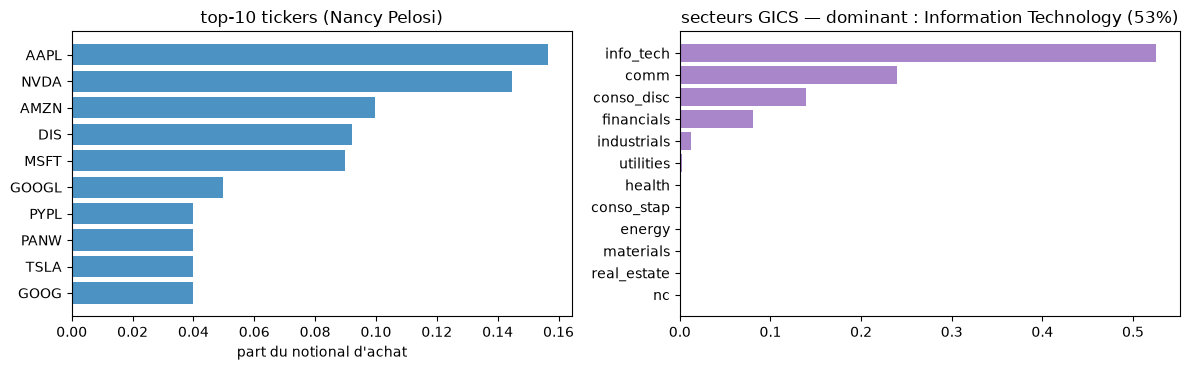

In [43]:
_r = M.loc[DEMO_BID]
_tk10 = _r["top10_tickers"].split("|")
_parts10 = (dfx[(dfx.bioguide_id == DEMO_BID) & (dfx.op == "buy")]
            .groupby("ticker")["size_usd"].sum().reindex(_tk10) / _r["notional_buy"])
_sc = list(SECT_COLS.values()) + ["sect_nc"]
_sv = _r[_sc].astype(float).sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].barh(_tk10[::-1], _parts10.values[::-1], color=C_M, alpha=.8)
ax[0].set_title(f"top-10 tickers ({DEMO_NOM})"); ax[0].set_xlabel("part du notional d'achat")
ax[1].barh([s.replace('sect_', '') for s in _sv.index[::-1]], _sv.values[::-1], color="tab:purple", alpha=.8)
ax[1].set_title(f"secteurs GICS — dominant : {_r['sect_dom']} ({_r['part_sect_dom']:.0%})")
plt.tight_layout(); plt.show()

## §8 `membres` — famille E : comportement

**But** : trois comportements — le membre achète-t-il dans les secteurs que ses comités
supervisent ? revient-il sur les mêmes titres ? achète-t-il ce que d'autres membres achètent
en même temps ?

$$\texttt{part\_ci\_achats}_m = \mathbb{P}_j\big(\mathrm{GICS}(k_j) \in \mathcal{J}(\texttt{comites}_j)
\;\big|\; d_j = \text{buy}\big) \qquad (\text{alignement comité} \times \text{secteur})$$

$$\texttt{part\_trades\_repetes}_m = \mathbb{P}_j\big(\exists\, j' : k_{j'} = k_j,\ \tau_{j'} < \tau_j\big), \qquad
\texttt{part\_coachat}_m = \mathbb{P}_j\big(\#\{m' \text{ acheteurs de } k_j \text{ le même mois}\} \ge 3
\;\big|\; d_j = \text{buy}\big)$$

In [44]:
# flag ci au niveau trade : les comités portés par le trade lui-même (point-in-time)
_codes_tr = dfx["committee_membership"].map(codes_racine)
_juri_tr = _codes_tr.map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs]) if cs else frozenset())
dfx["ci"] = [s in sm for s, sm in zip(dfx["sector_gics"], _juri_tr)]
M["part_ci_achats"] = dfx[dfx.op == "buy"].groupby("bioguide_id")["ci"].mean()

# répétition : trade sur un ticker déjà tradé avant par le même membre
_o = dfx.sort_values("traded")
dfx["repete"] = _o.groupby(["bioguide_id", "ticker"]).cumcount().reindex(dfx.index) > 0
M["part_trades_repetes"] = dfx.groupby("bioguide_id")["repete"].mean()

# co-achat : (ticker, mois) avec >= 3 acheteurs distincts
_bm = dfx[dfx.op == "buy"].copy()
_bm["ym"] = _bm["traded"].dt.to_period("M")
_co = _bm.groupby(["ym", "ticker"])["bioguide_id"].transform("nunique")
_bm["coachat3"] = _co >= 3
M["part_coachat"] = _bm.groupby("bioguide_id")["coachat3"].mean()
print(f"famille E : part_ci moyenne (achats, nb) = {dfx.loc[dfx.op == 'buy', 'ci'].mean():.1%}")

famille E : part_ci moyenne (achats, nb) = 16.4%


### §8.1 Validation — le taux d'alignement, recoupé sur deux périmètres

Le taux d'achats « alignés comité » dépend du périmètre. Sur les **actions seules** (toutes années,
re-dépôts identiques dédupliqués, sans filtre prix), les valeurs de référence sont 17,0 % (en nombre)
/ 15,2 % (en $) : la cellule les vérifie, puis affiche le taux sur le périmètre $\mathcal{T}$ des
tables de ce notebook (actions + ETF couverts prix).

In [45]:
# périmètre « actions seules » : re-dépôts identiques dédupliqués + asset_class == stock
_fl = _raw.drop_duplicates(subset=["natural_key_hash"], keep="first")
_fl = _fl[_fl["asset_class"] == "stock"].copy()
_cd = _fl["committee_membership"].map(codes_racine)
_ju = _cd.map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs]) if cs else frozenset())
_fl["ci"] = [s in sm for s, sm in zip(_fl["sector_gics"], _ju)]
_ci_nb_08 = _fl.loc[_fl["direction"] == "buy", "ci"].mean()
_ci_usd_08 = _fl.loc[_fl["direction"] == "buy"].groupby("ci")["amount_midpoint"].sum()
_ci_usd_part_08 = _ci_usd_08.get(True, 0) / _ci_usd_08.sum()
assert round(_ci_nb_08, 3) == 0.170, _ci_nb_08          # valeur de référence : 17,0 %
assert round(_ci_usd_part_08, 3) == 0.152, _ci_usd_part_08   # 15,2 % en $
for c in ("part_ci_achats", "part_trades_repetes", "part_coachat"):
    assert M[c].dropna().between(0, 1).all(), c
_ci_T = dfx.loc[dfx.op == "buy", "ci"].mean()
print(f"§8.1 OK — actions seules : {_ci_nb_08:.1%} (nb) / {_ci_usd_part_08:.1%} ($) | "
      f"sur 𝒯 (les tables de ce notebook) : {_ci_T:.1%}")

§8.1 OK — actions seules : 17.0% (nb) / 15.2% ($) | sur 𝒯 (les tables de ce notebook) : 16.4%


**Aperçu (tableau)** — comportement, les 8 membres les plus actifs :

In [46]:
(M.sort_values("n_trades", ascending=False)
  [["name", "part_ci_achats", "part_trades_repetes", "part_coachat"]]
  .head(8).round(3))

,name,part_ci_achats,part_trades_repetes,part_coachat
bioguide_id,,,,
K000389,Rohit Khanna,0.147,0.970,0.086
M001157,Michael T. McCaul,0.118,0.964,0.087
R000586,James B. Renacci,0.291,0.860,0.061
G000583,Josh Gottheimer,0.251,0.843,0.165
R000582,David P. Roe,0.037,0.864,0.184
M001193,Thomas MacArthur,0.162,0.834,0.086
H001086,Diana Harshbarger,0.322,0.931,0.144
C001123,Gilbert Cisneros,0.220,0.735,0.115


### §8.2 Démo — son comportement, comparé à la médiane des éligibles

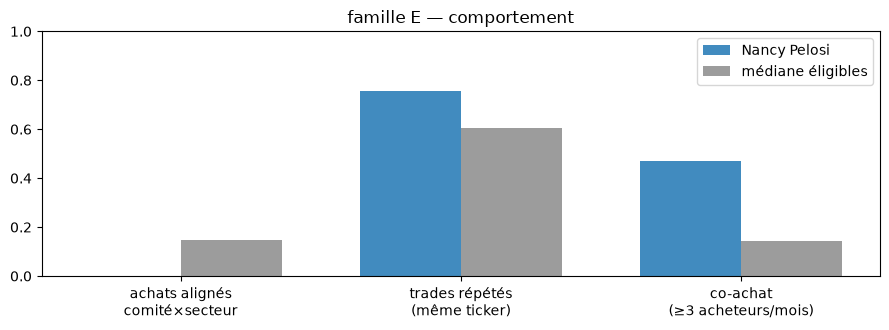

In [47]:
_r = M.loc[DEMO_BID]; _e = M[M.eligible]
_labels = ["achats alignés\ncomité×secteur", "trades répétés\n(même ticker)", "co-achat\n(≥3 acheteurs/mois)"]
_cols = ["part_ci_achats", "part_trades_repetes", "part_coachat"]
fig, ax = plt.subplots(figsize=(9, 3.4))
_xpos = np.arange(3)
ax.bar(_xpos - 0.18, [_r[c] for c in _cols], 0.36, color=C_M, alpha=.85, label=DEMO_NOM)
ax.bar(_xpos + 0.18, [_e[c].median() for c in _cols], 0.36, color=C_SPY, alpha=.7, label="médiane éligibles")
ax.set_xticks(_xpos); ax.set_xticklabels(_labels); ax.set_ylim(0, 1); ax.legend()
ax.set_title("famille E — comportement")
plt.tight_layout(); plt.show()

## §9 `tickers` — familles A (identité) et B (flux Congrès)

**But** : la même donnée vue par titre — qui du Congrès achète/vend chaque action, combien, quand.

$\mathcal{K}$ = les 4 618 tickers de $\mathcal{T}^{brut}$. Identité par $\operatorname{mode}$ sur les trades ;
flux sur $\mathcal{T}$ (sauf $\texttt{n\_trades\_brut}$) :

$$\texttt{notional\_net}_k = \sum_{j : k_j = k,\, d_j = \text{buy}} A_j - \sum_{j : k_j = k,\, d_j = \text{sell}} A_j,
\qquad
\texttt{part\_dem}_k = \frac{\sum_{j\,\text{buy},\ \text{Democrat}} A_j}{\sum_{j\,\text{buy}} A_j}$$

$$\texttt{coachat\_max}_k = \max_{\text{mois}} \#\{m : m \text{ achète } k \text{ ce mois}\}, \qquad
\texttt{n\_mois\_actifs}_k = \#\{(\text{année},\text{mois}) : \exists\, j\}$$

In [48]:
_tb = dfb.groupby("ticker")
K = pd.DataFrame(index=pd.Index(sorted(dfb.ticker.dropna().unique()), name="ticker"))
K["description"] = _tb["asset_description"].agg(_mode).astype(str).str[:80]
K["asset_class"] = _tb["asset_class"].agg(_mode)
K["is_broad_etf"] = _tb["is_broad_etf"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())
K["sector_gics"] = _tb["sector_gics"].agg(_mode)
K["etf_proxy"] = _tb["etf_proxy"].agg(_mode)
K["is_delisted"] = _tb["is_delisted"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())
K["delist_type"] = _tb["delist_type"].agg(_mode)
K["flag_price_caution"] = _tb["flag_price_caution"].agg(lambda s: pd.Series(s).astype(str).str.lower().isin(["true", "1", "1.0"]).any())

_tx = dfx.groupby("ticker")
K["n_trades_brut"] = _tb.size()
K["n_trades"] = _tx.size()
K["n_buy"] = _tx["op"].agg(lambda s: int((s == "buy").sum()))
K["n_sell"] = _tx["op"].agg(lambda s: int((s == "sell").sum()))
K["notional_buy"] = dfx[dfx.op == "buy"].groupby("ticker")["size_usd"].sum()
K["notional_sell"] = dfx[dfx.op == "sell"].groupby("ticker")["size_usd"].sum()
K["notional_net"] = K["notional_buy"].fillna(0) - K["notional_sell"].fillna(0)
K["n_membres"] = _tx["bioguide_id"].nunique()
K["n_membres_buy"] = dfx[dfx.op == "buy"].groupby("ticker")["bioguide_id"].nunique()
K["n_membres_sell"] = dfx[dfx.op == "sell"].groupby("ticker")["bioguide_id"].nunique()
_dem = dfx[(dfx.op == "buy") & (dfx.party == "Democrat")].groupby("ticker")["size_usd"].sum()
K["part_dem"] = (_dem / K["notional_buy"]).where(K["notional_buy"].notna())
K["part_senate"] = _tx["chamber"].agg(lambda s: (s == "senate").mean())
K["part_conjoint"] = _tx["owner_n"].agg(lambda s: (s == "conjoint").mean())
K["part_ci_achats"] = dfx[dfx.op == "buy"].groupby("ticker")["ci"].mean()
K["first_trade"] = _tx["traded"].min().dt.date
K["last_trade"] = _tx["traded"].max().dt.date
K["n_mois_actifs"] = _tx["traded"].agg(lambda s: s.dt.to_period("M").nunique())
K["coachat_max"] = _bm.groupby(["ticker", "ym"])["bioguide_id"].nunique().groupby(level=0).max()
_tm = dfx.groupby(["ticker", "bioguide_id"])["size_usd"].sum().sort_values(ascending=False)
_tm3 = (_tm.groupby(level=0).head(3).reset_index()
        .sort_values(["ticker", "size_usd"], ascending=[True, False]))
K["top_membres"] = _tm3.groupby("ticker")["bioguide_id"].agg("|".join)
print(f"K : {len(K)} tickers × {K.shape[1]} colonnes")

K : 4618 tickers × 27 colonnes


### §9.1 Validation

In [49]:
assert len(K) == 4618 and K.index.is_unique, len(K)
assert int(K["n_trades_brut"].sum()) == 134429
assert int(K["n_trades"].fillna(0).sum()) == 118029
assert K["part_dem"].dropna().between(0, 1).all() and K["part_senate"].dropna().between(0, 1).all()
assert int(K["n_trades"].notna().sum()) == 3289          # tickers de 𝒯 = ceux couverts prix
print("§9.1 OK — 4 618 tickers, sommes exactes, 3 289 dans 𝒯")

§9.1 OK — 4 618 tickers, sommes exactes, 3 289 dans 𝒯


**Aperçu (tableau)** — flux Congrès, les 8 tickers les plus tradés :

In [50]:
(K.sort_values("n_trades", ascending=False)
  [["description", "sector_gics", "n_trades", "n_buy", "n_sell", "notional_buy", "notional_net",
    "n_membres", "coachat_max", "first_trade", "last_trade"]]
  .head(8).round(0))

,description,sector_gics,n_trades,n_buy,n_sell,notional_buy,notional_net,n_membres,coachat_max,first_trade,last_trade
ticker,,,,,,,,,,,
AAPL,Apple Inc.,Information Technology,1260.0,585.0,675.0,28947652.0,-56738706.0,151.0,12.0,2013-04-19,2026-06-16
MSFT,Microsoft Corporation,Information Technology,1238.0,606.0,632.0,93307910.0,-34664830.0,144.0,14.0,2013-07-19,2026-06-16
AMZN,"Amazon.com, Inc.",Consumer Discretionary,976.0,565.0,411.0,29045136.0,4215428.0,126.0,10.0,2013-05-09,2026-06-16
GOOGL,ALPHABET INC. CMN CLASS A,Communication Services,885.0,399.0,486.0,14792200.0,-12171544.0,95.0,6.0,2013-01-17,2026-06-16
META,"Meta Platforms, Inc. - Class A Common Stock",Communication Services,831.0,422.0,409.0,14951938.0,-7303512.0,90.0,6.0,2013-09-13,2026-06-16
NVDA,NVIDIA Corporation - Common Stock,Information Technology,660.0,372.0,288.0,26357565.0,2635421.0,74.0,8.0,2015-05-14,2026-06-16
DIS,WALT DISNEY COMPANY (THE) CMN,Communication Services,656.0,362.0,294.0,12792181.0,3030034.0,97.0,8.0,2013-12-31,2026-05-27
UNH,UNITEDHEALTH GROUP INC,Health Care,646.0,302.0,344.0,10682152.0,-168160.0,80.0,9.0,2013-04-26,2026-05-15


## §10 `tickers` — familles C (marché) et D (croisement)

**But** : le profil de marché de chaque titre (volatilité, bêta, liquidité) et ce que fait le titre
dans les semaines qui suivent les achats du Congrès.

**Marché** — sur la série de prix **brute** (jours réellement cotés, PAS la version forward-fill du
moteur : le ffill fabriquerait des rendements nuls et une vol biaisée vers 0 pour les délistés) :

$$\texttt{vol\_ann}_k = \sigma\big(\Delta \log P_k\big)\sqrt{252}, \qquad
\texttt{beta\_spy}_k = \frac{\operatorname{cov}(r_k, r_{SPY})}{\operatorname{var}(r_{SPY})}
\;\;(\ge 126 \text{ obs communes}), \qquad
\texttt{adv\_med}_k = \operatorname{med}_t\big(P^{raw}_k(t)\, \mathrm{Vol}_k(t)\big)$$

**Croisement** — event-study descriptif sur les **achats** (entrée $J{+}1(\tau_j)$, brut vs SPY) :

$$\texttt{exces\_H}_k = \overline{\Big[\tfrac{P_k(J{+}1(\tau_j)+H)}{P_k(J{+}1(\tau_j))}
- \tfrac{SPY(J{+}1(\tau_j)+H)}{SPY(J{+}1(\tau_j))}\Big]}_{j\,:\,k_j = k,\ d_j = \text{buy}},
\qquad H \in \{21, 63\}$$

In [51]:
VOLDIR = os.path.join(BASE, "cache", "volume_v1")
_mkt = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index().dropna())
    lr = np.log(s).diff().dropna()
    row = dict(px_first=s.index[0].date(), px_last=s.index[-1].date(), px_n_obs=len(s),
               vol_ann=float(lr.std() * np.sqrt(252)) if len(lr) > 20 else np.nan,
               ret_total=float(s.iloc[-1] / s.iloc[0] - 1),
               cagr_fenetre=float((s.iloc[-1] / s.iloc[0]) ** (252 / max(len(s), 1)) - 1) if len(s) > 20 else np.nan,
               maxdd=float((s / s.cummax() - 1).min()))
    _rk = s.pct_change().dropna()
    _pair = pd.concat([_rk.rename("y"), r_spy.reindex(_rk.index).rename("x")], axis=1).dropna()
    row["beta_spy"] = float(np.polyfit(_pair["x"], _pair["y"], 1)[0]) if len(_pair) >= 126 else np.nan
    _vf = os.path.join(VOLDIR, tk + ".csv")
    if os.path.exists(_vf):
        _v = pd.read_csv(_vf)
        row["adv_med"] = float((_v["close_raw"] * _v["volume"]).median())
    else:
        row["adv_med"] = np.nan
    _mkt[tk] = row
_mkt = pd.DataFrame(_mkt).T
K["px_couvert"] = K.index.isin(need)
for c in _mkt.columns:
    K[c] = _mkt[c]
print(f"marché : {len(_mkt)} tickers | ADV disponible : {int(K.adv_med.notna().sum())}")

marché : 3289 tickers | ADV disponible : 3247


In [52]:
# event-study 21/63 j sur les achats (mêmes tableaux vectorisés que §5bis)
for H, nom in [(21, "exces_21j_moy"), (63, "exces_63j_moy")]:
    iH = i0 + H
    okH = (cols >= 0) & (iH < len(cal)) & (i0 <= _LAST[np.maximum(cols, 0)])
    xH = np.full(len(_b), np.nan)
    rH, c0H, c1H = cols[okH], i0[okH], iH[okH]
    p0H, p1H = PXV[c0H, rH], PXV[c1H, rH]
    b0H, b1H = SPYV[c0H], SPYV[c1H]
    vH = ~(np.isnan(p0H) | np.isnan(p1H)) & (p0H > 0) & (b0H > 0)
    _r = np.full(int(okH.sum()), np.nan)
    _r[vH] = (p1H[vH] / p0H[vH] - 1) - (b1H[vH] / b0H[vH] - 1)
    xH[okH] = _r
    _b[nom] = xH
_ge = _b.dropna(subset=["exces_21j_moy"]).groupby("ticker")
K["exces_21j_moy"] = _ge["exces_21j_moy"].mean()
K["exces_63j_moy"] = _b.dropna(subset=["exces_63j_moy"]).groupby("ticker")["exces_63j_moy"].mean()
K["n_achats_evalues"] = _ge.size()
print(f"event-study : {int(K.n_achats_evalues.notna().sum())} tickers avec ≥1 achat évalué")

event-study : 2609 tickers avec ≥1 achat évalué


### §10.1 Validation

In [53]:
assert abs(K.loc["SPY", "beta_spy"] - 1) < 1e-6                       # SPY sur lui-même
assert 0.10 < K.loc["SPY", "vol_ann"] < 0.30
# délistés : une bonne part des séries brutes s'arrête avant la fin du calendrier
# (pas toutes : certains « faillis » cotent encore en OTC chez Yahoo, ex. BBBY)
_dl = K[K.is_delisted & K.px_couvert]
_stoppees = pd.to_datetime(_dl["px_last"]) < cal.max() - pd.Timedelta(days=5)
assert len(_dl) and _stoppees.any(), "aucun délisté à série arrêtée ?"
_ex_stop = _stoppees[_stoppees].index[0]
assert (K["n_achats_evalues"].fillna(0) <= K["n_buy"].fillna(0)).all()
assert K["vol_ann"].dropna().between(0, 5).all()
print(f"§10.1 OK — beta(SPY)=1, vol(SPY)={K.loc['SPY','vol_ann']:.0%} | délistés à série arrêtée : "
      f"{_stoppees.mean():.0%} de {len(_dl)} (ex. {_ex_stop}, dernier prix {K.loc[_ex_stop, 'px_last']})")

§10.1 OK — beta(SPY)=1, vol(SPY)=17% | délistés à série arrêtée : 30% de 10 (ex. CA, dernier prix 2026-05-26)


**Aperçu (tableau)** — marché et croisement, les 8 tickers aux plus nombreux achats évalués :

In [54]:
(K.sort_values("n_achats_evalues", ascending=False)
  [["description", "vol_ann", "beta_spy", "adv_med", "cagr_fenetre", "maxdd",
    "exces_21j_moy", "exces_63j_moy", "n_achats_evalues"]]
  .head(8).round(3))

,description,vol_ann,beta_spy,adv_med,cagr_fenetre,maxdd,exces_21j_moy,exces_63j_moy,n_achats_evalues
ticker,,,,,,,,,
MSFT,Microsoft Corporation,0.261865,1.158218,3402713799.217224,0.224456,-0.371485,0.005,0.026,604.0
AAPL,Apple Inc.,0.283417,1.173587,8248417608.201599,0.249489,-0.437972,0.011,0.033,584.0
AMZN,"Amazon.com, Inc.",0.322698,1.194702,5733082056.884766,0.256261,-0.561453,0.008,0.030,565.0
META,"Meta Platforms, Inc. - Class A Common Stock",0.398127,1.272631,3831081554.639053,0.214114,-0.767361,0.010,0.045,421.0
GOOGL,ALPHABET INC. CMN CLASS A,0.275764,1.137929,2271767257.232666,0.237493,-0.4432,0.002,0.009,398.0
NVDA,NVIDIA Corporation - Common Stock,0.4438,1.709451,2747715393.02063,0.557315,-0.663351,0.045,0.135,372.0
DIS,WALT DISNEY COMPANY (THE) CMN,0.262306,1.003048,852551674.034119,0.07871,-0.607152,-0.006,-0.016,362.0
V,Visa Inc.,0.236395,1.01654,1073897702.033997,0.209231,-0.363649,0.005,0.008,314.0


### §9.2 Démo — un ticker vu du Congrès : prix + trades superposés, flux net mensuel

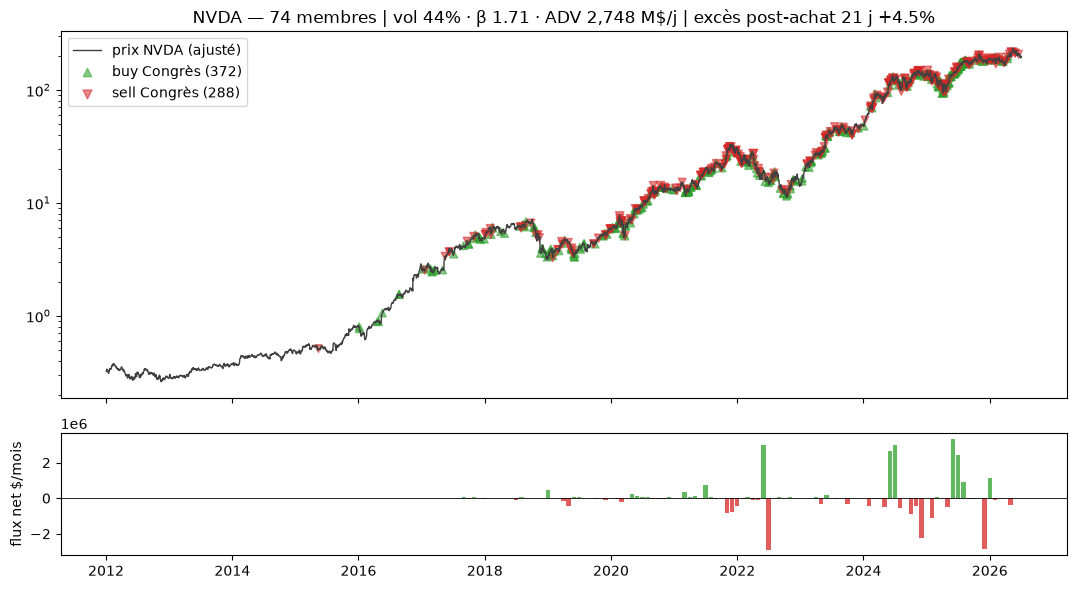

In [55]:
_pxd = (pd.read_csv(os.path.join(PRICES, TICKER_DEMO + ".csv"), parse_dates=["Date"])
          .set_index("Date")["close"].sort_index().dropna())
_gt = dfx[dfx.ticker == TICKER_DEMO]
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(_pxd, color="0.25", lw=1.0, label=f"prix {TICKER_DEMO} (ajusté)")
for _dop, _dc, _dmk in [("buy", C_BUY, "^"), ("sell", C_SELL, "v")]:
    _ds = _gt[_gt.op == _dop]
    _dy = _pxd.reindex(pd.DatetimeIndex(_ds["traded"]), method="ffill")
    ax[0].scatter(_ds["traded"], _dy.values, s=(np.log10(_ds["size_usd"].clip(lower=10)) * 8),
                  color=_dc, marker=_dmk, alpha=.55, label=f"{_dop} Congrès ({len(_ds):,})")
ax[0].set_yscale("log"); ax[0].legend(loc="upper left")
_rk = K.loc[TICKER_DEMO]
ax[0].set_title(f"{TICKER_DEMO} — {int(_rk['n_membres'])} membres | vol {_rk['vol_ann']:.0%} · β {_rk['beta_spy']:.2f} · "
                f"ADV {_rk['adv_med']/1e6:,.0f} M$/j | excès post-achat 21 j {_rk['exces_21j_moy']:+.1%}")
_flux = (_gt.assign(sgn=np.where(_gt.op == "buy", 1.0, -1.0) * _gt["size_usd"])
         .groupby(_gt["traded"].dt.to_period("M"))["sgn"].sum())
ax[1].bar(_flux.index.to_timestamp(), _flux.values, width=25,
          color=[C_BUY if v > 0 else C_SELL for v in _flux.values], alpha=.75)
ax[1].axhline(0, color="k", lw=0.6); ax[1].set_ylabel("flux net $/mois")
plt.tight_layout(); plt.show()

## §11 `membres_annees` — panel (membre, année civile)

**But** : l'activité et la performance de chaque membre, année par année.

Activité depuis $\mathcal{T}$ ; performance depuis la tranche annuelle de $r_m$
(NaN si $< 40$ jours actifs dans l'année — seuil anti-bruit) :

$$\texttt{ret\_annee}_{m,Y} = \prod_{t \in Y}(1 + r_m(t)) - 1, \qquad
\texttt{exces\_spy\_annee}_{m,Y} = \texttt{ret\_annee}_{m,Y} - \Big[\prod_{t \in Y}(1 + r_{SPY}(t)) - 1\Big]
\;\;(\text{mêmes jours})$$

In [56]:
_pa = dfx.assign(annee=dfx["traded"].dt.year).groupby(["bioguide_id", "annee"])
PAN = pd.DataFrame({
    "n_trades": _pa.size(),
    "n_buy": _pa["op"].agg(lambda s: int((s == "buy").sum())),
    "buy_share": _pa["op"].agg(lambda s: (s == "buy").mean()),
    "notional": _pa["size_usd"].sum(),
    "n_tickers": _pa["ticker"].nunique(),
    "sect_dom": _pa["sector_gics"].agg(_mode),
})
_rowsy = {}
for b, r in wf_ret.items():
    for Y, ry in r.groupby(r.index.year):
        rs = r_spy.reindex(ry.index).fillna(0.0)
        _rowsy[(b, Y)] = dict(
            n_days=len(ry),
            vol=float(ry.std() * np.sqrt(252)) if len(ry) >= 40 else np.nan,
            sharpe=float(ry.mean() / ry.std() * np.sqrt(252)) if (len(ry) >= 40 and ry.std() > 0) else np.nan,
            ret_annee=float((1 + ry).prod() - 1) if len(ry) >= 40 else np.nan,
            exces_spy_annee=float((1 + ry).prod() - (1 + rs).prod()) if len(ry) >= 40 else np.nan)
_pf = pd.DataFrame(_rowsy).T
_pf.index = pd.MultiIndex.from_tuples(_pf.index, names=["bioguide_id", "annee"])
PAN = PAN.join(_pf, how="outer")
PAN.index.names = ["bioguide_id", "annee"]
print(f"panel : {len(PAN)} lignes (membre, année) | avec perf annuelle : {int(PAN.ret_annee.notna().sum())}")

panel : 2628 lignes (membre, année) | avec perf annuelle : 2398


### §11.1 Validation

In [57]:
assert int(PAN["n_trades"].fillna(0).sum()) == 118029
_pel24 = float(PAN.loc[(PELOSI_BID, 2024), "ret_annee"])   # ancré Pelosi (indépendant du membre de démo)
assert abs(_pel24 - 0.385) < 0.003, _pel24                     # valeur de référence : Pelosi 2024 = +38,5 %
assert PAN.index.is_unique
print(f"§11.1 OK — Σ trades 118 029 | Pelosi 2024 = {_pel24:+.1%} (valeur de référence : +38,5 %)")

§11.1 OK — Σ trades 118 029 | Pelosi 2024 = +38.5% (valeur de référence : +38,5 %)


**Aperçu (tableau)** — panel, les 8 (membre, année) aux plus gros notionals :

In [58]:
(PAN.join(M["name"], on="bioguide_id").sort_values("notional", ascending=False)
  [["name", "n_trades", "n_buy", "buy_share", "notional", "n_tickers", "sect_dom",
    "vol", "sharpe", "ret_annee", "exces_spy_annee"]]
  .head(8).round(3))

name  n_trades   n_buy  buy_share  \
bioguide_id annee                                                   
H001086     2021   Diana Harshbarger    1417.0   574.0      0.405   
K000389     2021        Rohit Khanna    2829.0  1798.0      0.636   
H001086     2022   Diana Harshbarger     998.0   362.0      0.363   
L000594     2020      Kelly Loeffler     209.0    43.0      0.206   
B001135     2015      RICHARD M BURR      84.0    42.0      0.500   
M001157     2018   Michael T. McCaul    2370.0  1146.0      0.484   
            2021   Michael T. McCaul    1177.0   441.0      0.375   
            2020   Michael T. McCaul    1421.0   799.0      0.562   

                      notional  n_tickers                sect_dom    vol  \
bioguide_id annee                                                          
H001086     2021   232197819.5      130.0             Industrials  0.206   
K000389     2021   161015914.0      586.0              Financials  0.141   
H001086     2022   136450563.0      121.0  Information Technology  0.217   
L000594     2020   113850104.5       89.0              Financials  0.453   
B001135     2015   112439041.5       24.0              Financials  0.159   
M001157     2018    94764185.0      192.0             Industrials  0.173   
            2021    91144589.0      158.0              Financials  0.148   
            2020    86134216.0      200.0              Financials  0.361   

                   sharpe  ret_annee  exces_spy_annee  
bioguide_id annee                                      
H001086     2021    0.983      0.199           -0.088  
K000389     2021    1.734      0.264           -0.023  
H001086     2022   -0.263     -0.077            0.105  
L000594     2020    0.823      0.270            0.140  
B001135     2015    0.115      0.006           -0.007  
M001157     2018   -0.714     -0.129           -0.083  
            2021    1.458      0.227           -0.060  
            2020    0.510      0.126           -0.057

### §11.2 Démo — l'année par année du membre (le panel en une figure)

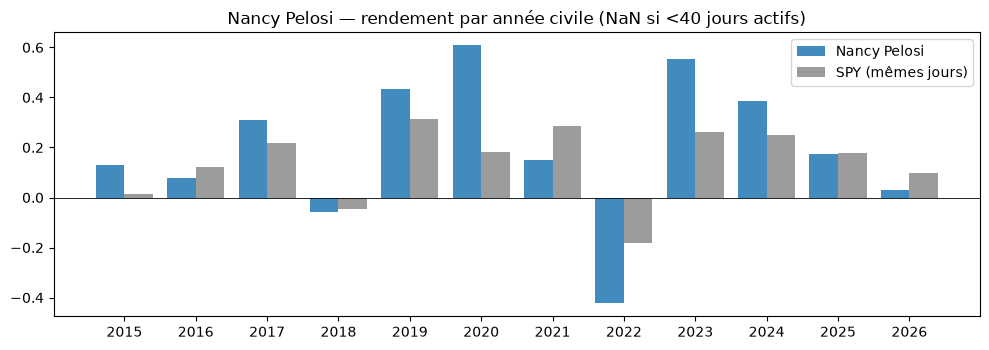

,n_trades,notional,n_tickers,vol,sharpe,ret_annee,exces_spy_annee
annee,,,,,,,
2015,5.0,832502.5,3.0,0.226,0.652,0.129,0.117
2016,6.0,1758003.0,5.0,0.159,0.561,0.080,-0.040
2017,10.0,6390505.0,4.0,0.125,2.249,0.311,0.094
2018,11.0,7350005.5,5.0,0.270,-0.090,-0.059,-0.013
2019,4.0,533002.0,2.0,0.187,2.015,0.432,0.120
2020,21.0,26600010.5,12.0,0.367,1.476,0.609,0.425
2021,8.0,12750004.0,5.0,0.194,0.821,0.150,-0.137
2022,24.0,37675012.0,11.0,0.365,-1.330,-0.423,-0.242
2023,4.0,2625002.0,2.0,0.198,2.340,0.554,0.292


In [59]:
_pm = PAN.loc[DEMO_BID].dropna(subset=["ret_annee"])
fig, ax = plt.subplots(figsize=(10, 3.6))
_ys = _pm.index.astype(int)
ax.bar(_ys - 0.2, _pm["ret_annee"].values, 0.4, color=C_M, alpha=.85, label=DEMO_NOM)
ax.bar(_ys + 0.2, [_pm.loc[y, "ret_annee"] - _pm.loc[y, "exces_spy_annee"] for y in _pm.index],
       0.4, color=C_SPY, alpha=.7, label="SPY (mêmes jours)")
ax.axhline(0, color="k", lw=0.6); ax.set_xticks(_ys); ax.legend()
ax.set_title(f"{DEMO_NOM} — rendement par année civile (NaN si <40 jours actifs)")
plt.tight_layout(); plt.show()
display(_pm[["n_trades", "notional", "n_tickers", "vol", "sharpe", "ret_annee", "exces_spy_annee"]].round(3))

## §12 Contrôles croisés globaux

Les deux tables décrivent la même donnée : toutes les sommes doivent se recouper **exactement**
(trades, notionals, paires membre-ticker, bornes de dates). Aucun CSV n'est écrit si un contrôle échoue.

In [60]:
# 1. sommes de trades identiques entre les deux tables et le périmètre
assert int(M["n_trades"].fillna(0).sum()) == int(K["n_trades"].fillna(0).sum()) == 118029
assert int(M["n_trades_brut"].sum()) == int(K["n_trades_brut"].sum()) == 134429
# 2. notionals au centime
assert abs(M["notional_buy"].fillna(0).sum() - K["notional_buy"].fillna(0).sum()) < 0.01
assert abs(M["notional_sell"].fillna(0).sum() - K["notional_sell"].fillna(0).sum()) < 0.01
# 3. bipartite : Σ_k n_membres = # paires distinctes = Σ_m n_tickers
_paires_mk = dfx.groupby(["bioguide_id", "ticker"]).ngroups
assert int(K["n_membres"].fillna(0).sum()) == _paires_mk == int(M["n_tickers"].fillna(0).sum())
# 4. bornes temporelles cohérentes
assert M["first_trade"].dropna().min() == K["first_trade"].dropna().min()
assert M["last_trade"].dropna().max() == K["last_trade"].dropna().max()
# 5. compteurs population
assert len(M) == 372 and int(M["n_trades"].notna().sum()) == 359
assert int(M["reconstruit"].sum()) == 266 and int(M["eligible"].sum()) == 223
assert len(K) == 4618 and int(K["px_couvert"].sum()) == 3289
# 6. taux d'alignement comité identique vu des deux tables (pondéré par le nombre d'achats)
#    et égal à la moyenne calculée directement sur les trades
_ci_m = (M["part_ci_achats"] * M["n_buy"]).sum() / M["n_buy"].sum()
_ci_k = (K["part_ci_achats"] * K["n_buy"]).sum() / K["n_buy"].sum()
_ci_pool = dfx.loc[dfx.op == "buy", "ci"].mean()
assert abs(_ci_m - _ci_k) < 1e-12 and abs(_ci_m - _ci_pool) < 1e-12
# 7. épisodes FIFO (déjà §4.1) : 61 963 / 28 944 / 44 % — re-déclaré ici pour la trace
assert (len(_cl), len(_op)) == (61963, 28944)
# 8. cohérences internes
assert int((M["n_buy"].fillna(0) + M["n_sell"].fillna(0)).sum()) == 118029
assert not M["name"].astype(str).str.contains(r"\|").any()
assert not pd.Index(K.index.astype(str)).str.contains(r"\|").any()
print("§12 OK — les 8 contrôles croisés passent : les tables sont cohérentes entre elles")

§12 OK — les 8 contrôles croisés passent : les tables sont cohérentes entre elles


## §13 Écriture des CSV + dictionnaire des colonnes

Le dictionnaire est LA carte de lecture : une ligne par colonne (table, famille, définition, source,
type). Un `assert` garantit qu'il couvre exactement les colonnes réellement écrites.

In [61]:
TABLES = os.path.join(BASE, "tables")
os.makedirs(TABLES, exist_ok=True)

D = []   # (table, famille, colonne, définition, source, type)
def _d(table, fam, col, definition, source, typ):
    D.append(dict(table=table, famille=fam, colonne=col, definition=definition, source=source, type=typ))

# ---- membres : A identité ----
for c, dfn, src, ty in [
    ("name", "mode des variantes de nom (canonique 𝒯 prioritaire)", "dfx name_canon / dfb", "str"),
    ("party", "mode sur les trades", "dfb", "str"),
    ("chamber", "mode sur les trades (un House→Senate a un mode arbitraire)", "dfb", "str"),
    ("state", "state_district[:2]", "dfb", "str"),
    ("congress_first", "min(congress)", "dfb", "int"),
    ("congress_last", "max(congress)", "dfb", "int"),
    ("years_in_office", "max years_in_office", "table_congres_2014_2026.csv", "float"),
    ("leader", "bioguide ∈ leadership_2014_2026.csv (12 postes de parti)", "leadership CSV", "bool"),
    ("leader_postes", "postes occupés, séparés par |", "leadership CSV", "str"),
    ("comites", "∪ codes THOMAS racine (4 lettres), séparés par |", "committee_membership", "str"),
    ("comite_cle", "∃ trade avec committees_key_flag", "dfb", "bool"),
    ("secteurs_juridiction", "∪ COMITE_GICS[comites], séparés par |", "matrice §1", "str"),
    ("n_secteurs_juridiction", "cardinal de secteurs_juridiction", "dérivé", "int")]:
    _d("membres", "A identité", c, dfn, src, ty)
# ---- membres : B activité ----
for c, dfn, src, ty in [
    ("n_trades_brut", "# trades dans 𝒯^brut (134 429)", "dfb", "int"),
    ("n_trades", "# trades dans 𝒯 (118 029)", "dfx", "int"),
    ("n_buy", "# achats", "dfx", "int"), ("n_sell", "# ventes", "dfx", "int"),
    ("buy_share", "n_buy / n_trades", "dfx", "float"),
    ("notional_total", "Σ A_j (midpoint, censuré par intervalle)", "dfx", "float"),
    ("notional_buy", "Σ A_j achats", "dfx", "float"), ("notional_sell", "Σ A_j ventes", "dfx", "float"),
    ("taille_med", "med(A_j)", "dfx", "float"),
    ("pct_1re_fourchette", "P(A_j ≤ 8 000,5) — 1re tranche STOCK Act", "dfx", "float"),
    ("lag_med", "med(disclosure − traded) en jours", "dfx lag_days", "float"),
    ("part_late", "P(lag > 45 j)", "flag_late_filing", "float"),
    ("part_very_late", "P(lag > 365 j)", "flag_very_late_filing", "float"),
    ("owner_dom", "mode(owner normalisé : élu/conjoint/joint/enfant)", "dfx owner_n", "str"),
    ("part_conjoint", "P(owner = conjoint)", "dfx", "float"),
    ("part_self", "P(owner = élu)", "dfx", "float"),
    ("first_trade", "min(τ_j)", "dfx", "date"), ("last_trade", "max(τ_j)", "dfx", "date"),
    ("duree_activite_j", "(last − first) en jours", "dérivé", "int"),
    ("n_annees_actives", "# années avec ≥1 trade", "dfx", "int"),
    ("actif_12m", "last_trade ≥ max(cal) − 365 j", "dérivé", "bool")]:
    _d("membres", "B activité", c, dfn, src, ty)
# ---- membres : C portefeuille ----
for c, dfn, src, ty in [
    ("reconstruit", "série r_m disponible", "moteur §1", "bool"),
    ("n_days", "T_m = # jours actifs", "wf_ret", "int"),
    ("n_tickers", "# tickers distincts", "dfx", "int"),
    ("valeur_moy", "V̄_m sur jours actifs", "passe §4", "float"),
    ("valeur_fin", "V_m(dernier jour)", "passe §4", "float"),
    ("hhi", "moyenne_t Σ_k w²", "passe §4", "float"),
    ("n_eff", "1/HHI", "passe §4", "float"),
    ("top1", "moyenne_t max_k w", "passe §4", "float"),
    ("n_pos_moy", "# positions ouvertes moyen", "passe §4", "float"),
    ("turnover", "ΣA_j / (2 V̄) · 252/T", "passe §4", "float"),
    ("n_episodes_fermes", "# épisodes FIFO clos", "passe §4", "int"),
    ("duree_med_fermee", "médiane pondérée-parts des durées closes (j)", "fifo §6", "float"),
    ("duree_km_med", "inf{t : S_m(t) ≤ 0,5}, Kaplan-Meier pondéré (NaN si non atteinte)", "§6", "float"),
    ("part_ouverte", "parts encore détenues / parts totales", "fifo §6", "float"),
    ("n_allers_retours_30j", "# épisodes clos < 30 j", "fifo §6", "int"),
    ("top1_ticker", "1er ticker par notional d'achat", "dfx", "str"),
    ("top1_part", "sa part du notional d'achat", "dfx", "float"),
    ("top2_ticker", "2e ticker", "dfx", "str"), ("top2_part", "sa part", "dfx", "float"),
    ("top3_ticker", "3e ticker", "dfx", "str"), ("top3_part", "sa part", "dfx", "float"),
    ("top10_tickers", "top-10 tickers par notional d'achat, séparés par |", "dfx", "str"),
    ("sect_dom", "mode(GICS) des achats", "dfx", "str"),
    ("part_sect_dom", "part du notional d'achat du secteur dominant", "dérivé", "float")]:
    _d("membres", "C portefeuille", c, dfn, src, ty)
_SECT_DEF = {"sect_info_tech": "Information Technology", "sect_financials": "Financials",
             "sect_health": "Health Care", "sect_industrials": "Industrials",
             "sect_conso_disc": "Consumer Discretionary", "sect_comm": "Communication Services",
             "sect_conso_stap": "Consumer Staples", "sect_energy": "Energy",
             "sect_materials": "Materials", "sect_real_estate": "Real Estate",
             "sect_utilities": "Utilities", "sect_nc": "secteur GICS manquant"}
for c, lib in _SECT_DEF.items():
    _d("membres", "C portefeuille", c, f"part du notional d'achat en {lib} (Σ des 12 = 1)", "dfx sector_gics", "float")
# ---- membres : D risque/perf ----
for c, dfn, src, ty in [
    ("cagr", "NAV^(252/T) − 1", "moteur §1", "float"),
    ("vol", "σ(r_m)·√252", "moteur §1", "float"),
    ("sharpe", "r̄/σ·√252", "moteur §1", "float"),
    ("sortino", "r̄/σ(r⁻)·√252", "moteur §1", "float"),
    ("maxdd", "min(NAV/cummax − 1)", "moteur §1", "float"),
    ("t_sharpe", "sharpe·√(T/252)", "§5", "float"),
    ("ir", "IR vs SPY (β implicite = 1)", "moteur §1", "float"),
    ("t_ir", "IR·√(T/252)", "§5", "float"),
    ("beta", "pente OLS r_m ~ r_SPY", "moteur §1", "float"),
    ("alpha_ann", "(1+α)^252 − 1", "moteur §1", "float"),
    ("appraisal", "α/σ_ε·√252", "moteur §1", "float"),
    ("t_appr", "appraisal·√(T/252)", "moteur §1", "float"),
    ("exces_cagr_spy", "CAGR_m − CAGR_SPY (même fenêtre)", "moteur §1", "float"),
    ("eligible", "n_trades ≥ 10 et T ≥ 126", "§5", "bool")]:
    _d("membres", "D risque/perf", c, dfn, src, ty)
# ---- membres : F track record par trade ----
for c, dfn, src, ty in [
    ("n_trades_evalues", "# achats avec x_j calculable", "§5bis", "int"),
    ("hit_rate", "P(x_j > 0)", "§5bis", "float"),
    ("exces_moyen_trade", "moyenne des x_j", "§5bis", "float"),
    ("exces_med_trade", "med(x_j)", "§5bis", "float"),
    ("ret_brut_moyen_trade", "moyenne des rendements bruts", "§5bis", "float"),
    ("profit_factor", "min(Σx⁺/|Σx⁻|, 10)", "§5bis", "float"),
    ("t_exces_trade", "x̄/(σ_x/√n)", "§5bis", "float")]:
    _d("membres", "F track record", c, dfn, src, ty)
# ---- membres : E comportement ----
for c, dfn, src, ty in [
    ("part_ci_achats", "P(GICS du titre ∈ juridiction des comités du membre | achat)", "matrice §1", "float"),
    ("part_trades_repetes", "P(ticker déjà tradé avant par le membre)", "dfx", "float"),
    ("part_coachat", "P(achat dans un (ticker, mois) à ≥3 acheteurs)", "dfx", "float")]:
    _d("membres", "E comportement", c, dfn, src, ty)

# ---- tickers ----
for c, dfn, src, ty in [
    ("description", "mode(asset_description), 80 caractères", "dfb", "str"),
    ("asset_class", "mode", "dfb", "str"), ("is_broad_etf", "any", "dfb", "bool"),
    ("sector_gics", "mode", "dfb", "str"), ("etf_proxy", "mode (ETF SPDR du secteur)", "dfb", "str"),
    ("is_delisted", "any", "dfb", "bool"), ("delist_type", "mode (rachat/faillite/recyclage)", "dfb", "str"),
    ("flag_price_caution", "any", "dfb", "bool")]:
    _d("tickers", "A identité", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("n_trades_brut", "# trades 𝒯^brut", "dfb", "int"), ("n_trades", "# trades 𝒯", "dfx", "int"),
    ("n_buy", "# achats", "dfx", "int"), ("n_sell", "# ventes", "dfx", "int"),
    ("notional_buy", "Σ A_j achats", "dfx", "float"), ("notional_sell", "Σ A_j ventes", "dfx", "float"),
    ("notional_net", "buy − sell", "dérivé", "float"),
    ("n_membres", "# membres distincts", "dfx", "int"),
    ("n_membres_buy", "# acheteurs distincts", "dfx", "int"),
    ("n_membres_sell", "# vendeurs distincts", "dfx", "int"),
    ("part_dem", "part du notional d'achat venant de Démocrates", "dfx", "float"),
    ("part_senate", "part des trades venant du Sénat", "dfx", "float"),
    ("part_conjoint", "part des trades owner = conjoint", "dfx", "float"),
    ("part_ci_achats", "part des achats alignés comité×secteur", "matrice §1", "float"),
    ("first_trade", "min(τ_j)", "dfx", "date"), ("last_trade", "max(τ_j)", "dfx", "date"),
    ("n_mois_actifs", "# (année, mois) avec ≥1 trade", "dfx", "int"),
    ("coachat_max", "max mensuel d'acheteurs distincts", "dfx", "int"),
    ("top_membres", "top-3 bioguide_id par notional, séparés par |", "dfx", "str")]:
    _d("tickers", "B flux Congrès", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("px_couvert", "ticker ∈ cache prix exploitable", "prices_v2", "bool"),
    ("px_first", "1re cotation observée", "prices_v2 brut", "date"),
    ("px_last", "dernière cotation observée", "prices_v2 brut", "date"),
    ("px_n_obs", "# jours cotés", "prices_v2 brut", "int"),
    ("adv_med", "med(close_brut × volume) $/jour", "volume_v1", "float"),
    ("vol_ann", "σ(Δlog P)·√252 (jours cotés)", "prices_v2 brut", "float"),
    ("beta_spy", "pente OLS r_k ~ r_SPY (≥126 obs)", "prices_v2 brut", "float"),
    ("cagr_fenetre", "(P_last/P_first)^(252/n_obs) − 1", "prices_v2 brut", "float"),
    ("maxdd", "min(P/cummax − 1)", "prices_v2 brut", "float"),
    ("ret_total", "P_last/P_first − 1", "prices_v2 brut", "float")]:
    _d("tickers", "C marché", c, dfn, src, ty)
for c, dfn, src, ty in [
    ("exces_21j_moy", "moyenne des excès à 21 j des achats (entrée J+1 de τ, brut vs SPY)", "§10", "float"),
    ("exces_63j_moy", "idem à 63 j", "§10", "float"),
    ("n_achats_evalues", "# achats avec fenêtre 21 j complète", "§10", "int")]:
    _d("tickers", "D croisement", c, dfn, src, ty)

# ---- panel ----
for c, dfn, src, ty in [
    ("n_trades", "# trades de l'année", "dfx", "int"), ("n_buy", "# achats", "dfx", "int"),
    ("buy_share", "part d'achats", "dfx", "float"), ("notional", "Σ A_j", "dfx", "float"),
    ("n_tickers", "# tickers distincts", "dfx", "int"), ("sect_dom", "mode GICS", "dfx", "str"),
    ("n_days", "# jours actifs de r_m dans l'année", "wf_ret", "int"),
    ("vol", "σ(r_m)·√252 (NaN si <40 j)", "wf_ret", "float"),
    ("sharpe", "r̄/σ·√252 (NaN si <40 j)", "wf_ret", "float"),
    ("ret_annee", "Π(1+r_m) − 1 (NaN si <40 j)", "wf_ret", "float"),
    ("exces_spy_annee", "ret_annee − ret_SPY (mêmes jours)", "wf_ret", "float")]:
    _d("membres_annees", "panel", c, dfn, src, ty)

DICO = pd.DataFrame(D)
# le dictionnaire couvre EXACTEMENT les colonnes écrites
assert set(DICO[DICO.table == "membres"].colonne) == set(M.columns), \
    (set(DICO[DICO.table == "membres"].colonne) ^ set(M.columns))
assert set(DICO[DICO.table == "tickers"].colonne) == set(K.columns), \
    (set(DICO[DICO.table == "tickers"].colonne) ^ set(K.columns))
assert set(DICO[DICO.table == "membres_annees"].colonne) == set(PAN.columns), \
    (set(DICO[DICO.table == "membres_annees"].colonne) ^ set(PAN.columns))

M.to_csv(os.path.join(TABLES, "membres.csv"))
K.to_csv(os.path.join(TABLES, "tickers.csv"))
PAN.to_csv(os.path.join(TABLES, "membres_annees.csv"))
DICO.to_csv(os.path.join(TABLES, "dictionnaire_colonnes.csv"), index=False)
print(f"écrit dans {TABLES} :")
print(f"  membres.csv          {M.shape[0]} × {M.shape[1]}")
print(f"  tickers.csv          {K.shape[0]} × {K.shape[1]}")
print(f"  membres_annees.csv   {PAN.shape[0]} × {PAN.shape[1]}")
print(f"  dictionnaire_colonnes.csv  {len(DICO)} colonnes documentées")

écrit dans /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours/tables :
  membres.csv          372 × 94
  tickers.csv          4618 × 40
  membres_annees.csv   2628 × 11
  dictionnaire_colonnes.csv  145 colonnes documentées


### §13.2 Le dictionnaire complet — la carte de lecture des 3 fichiers

Chaque colonne de chaque CSV : sa définition, la section qui la calcule, son type.

In [62]:
pd.set_option("display.max_rows", 200)
DICO[DICO.table == "membres"].drop(columns="table").reset_index(drop=True)

,famille,colonne,definition,source,type
0,A identité,name,mode des variantes de nom (canonique 𝒯 priorit...,dfx name_canon / dfb,str
1,A identité,party,mode sur les trades,dfb,str
2,A identité,chamber,mode sur les trades (un House→Senate a un mode...,dfb,str
3,A identité,state,state_district[:2],dfb,str
4,A identité,congress_first,min(congress),dfb,int
5,A identité,congress_last,max(congress),dfb,int
6,A identité,years_in_office,max years_in_office,table_congres_2014_2026.csv,float
7,A identité,leader,bioguide ∈ leadership_2014_2026.csv (12 postes...,leadership CSV,bool
8,A identité,leader_postes,"postes occupés, séparés par |",leadership CSV,str
9,A identité,comites,"∪ codes THOMAS racine (4 lettres), séparés par |",committee_membership,str


In [63]:
DICO[DICO.table == "tickers"].drop(columns="table").reset_index(drop=True)

,famille,colonne,definition,source,type
0,A identité,description,"mode(asset_description), 80 caractères",dfb,str
1,A identité,asset_class,mode,dfb,str
2,A identité,is_broad_etf,any,dfb,bool
3,A identité,sector_gics,mode,dfb,str
4,A identité,etf_proxy,mode (ETF SPDR du secteur),dfb,str
5,A identité,is_delisted,any,dfb,bool
6,A identité,delist_type,mode (rachat/faillite/recyclage),dfb,str
7,A identité,flag_price_caution,any,dfb,bool
8,B flux Congrès,n_trades_brut,# trades 𝒯^brut,dfb,int
9,B flux Congrès,n_trades,# trades 𝒯,dfx,int


In [64]:
DICO[DICO.table == "membres_annees"].drop(columns="table").reset_index(drop=True)

,famille,colonne,definition,source,type
0,panel,n_trades,# trades de l'année,dfx,int
1,panel,n_buy,# achats,dfx,int
2,panel,buy_share,part d'achats,dfx,float
3,panel,notional,Σ A_j,dfx,float
4,panel,n_tickers,# tickers distincts,dfx,int
5,panel,sect_dom,mode GICS,dfx,str
6,panel,n_days,# jours actifs de r_m dans l'année,wf_ret,int
7,panel,vol,σ(r_m)·√252 (NaN si <40 j),wf_ret,float
8,panel,sharpe,r̄/σ·√252 (NaN si <40 j),wf_ret,float
9,panel,ret_annee,Π(1+r_m) − 1 (NaN si <40 j),wf_ret,float


### §13.1 Aperçu — trois distributions pour lire les tables

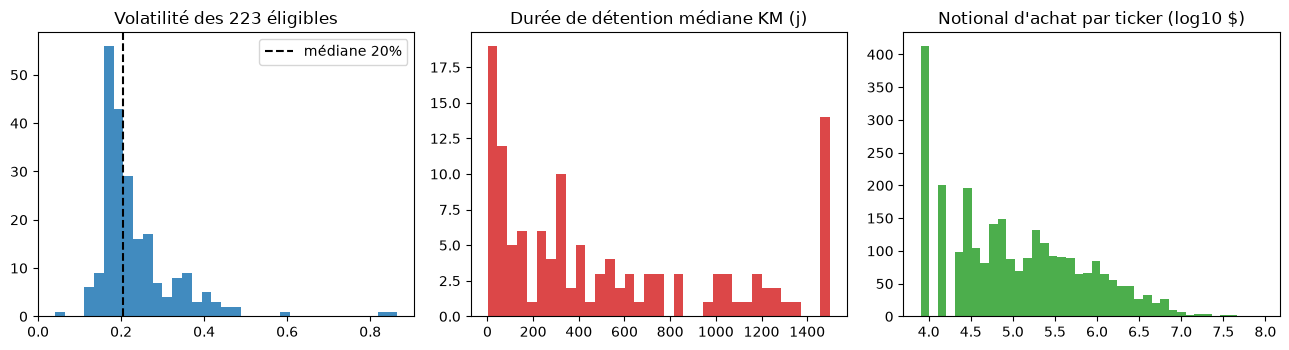

Les tables sont prêtes : membres.csv / tickers.csv / membres_annees.csv + dictionnaire_colonnes.csv


In [65]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
_e = M[M.eligible]
ax[0].hist(_e["vol"].dropna().clip(upper=1.0), bins=35, color="tab:blue", alpha=.85)
ax[0].axvline(float(_e["vol"].median()), color="k", ls="--", label=f"médiane {_e['vol'].median():.0%}")
ax[0].set_title("Volatilité des 223 éligibles"); ax[0].legend()
ax[1].hist(M["duree_km_med"].dropna().clip(upper=1500), bins=35, color="tab:red", alpha=.85)
ax[1].set_title("Durée de détention médiane KM (j)")
ax[2].hist(np.log10(K["notional_buy"].dropna().clip(lower=1)), bins=40, color="tab:green", alpha=.85)
ax[2].set_title("Notional d'achat par ticker (log10 $)")
plt.tight_layout(); plt.show()
print("Les tables sont prêtes : membres.csv / tickers.csv / membres_annees.csv + dictionnaire_colonnes.csv")